In [1]:
import sys, os
os.path.dirname(sys.executable)

'/clusterfs/nilah/sergio/miniconda3/envs/ESM_cambrian/bin'

In [2]:
sys.path.append('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/')
from ESMCBA.imports import *
from ESMCBA import other_utils

In [3]:
evaluations_df = pd.read_csv('../evaluations_full_02062025.csv')

In [4]:
evaluations_df['PT'] = np.where(
    evaluations_df['pretrain'].str.contains('Not', na=False),
    'Non-PT', 'PT'
)
evaluations_df['name'] = evaluations_df['PT'] + ' ' + evaluations_df['encoding'] + ' ' + evaluations_df['trained_blocks'].astype(str) + 'L'

In [5]:
# evaluations_df[evaluations_df['n_evaluations'] > 50].drop_duplicates('Model')

In [6]:
evaluations_df[(evaluations_df['HLA'] == 'A2601')]

,HLA,Losses,encoding,data_prop,trained_blocks,lr_transformer,lr_regression,n_evaluations,spearman,pearsonr,...,rmse,time,path,Model,rank_mse,rank_corr,rank_sum,pretrain,PT,name
25,A2601,Hubber,epitope,0.40,30,0.0001,0.0001,15,0.607143,0.681327,...,1.101394,2025-05-28 09:57:47,/global/scratch/users/sergiomar10/losses/ESMCB...,A2601 epitope,10.0,8.5,18.5,Pretrained,PT,PT epitope 30L
41,A2601,Hubber,HLA,0.40,0,NaN,5.0000,15,0.225000,0.189884,...,1.426992,2025-05-28 19:19:02,/global/scratch/users/sergiomar10/losses/ESMCB...,A2601 HLA,39.0,24.5,63.5,Not Pretrained,Non-PT,Non-PT HLA 0L
103,A2601,Hubber,epitope,0.40,30,0.0001,0.0001,15,0.600000,0.648963,...,1.093790,2025-05-28 22:52:42,/global/scratch/users/sergiomar10/losses/ESMCB...,A2601 epitope,8.0,12.0,20.0,Pretrained,PT,PT epitope 30L
178,A2601,Hubber,epitope,0.95,30,0.0001,0.0001,15,0.700000,0.803342,...,0.975368,2025-05-28 20:39:46,/global/scratch/users/sergiomar10/losses/ESMCB...,A2601 epitope,1.0,1.0,2.0,Pretrained,PT,PT epitope 30L
229,A2601,Hubber,epitope,0.40,30,0.0001,0.0001,15,0.485714,0.598083,...,1.143873,2025-05-28 22:47:19,/global/scratch/users/sergiomar10/losses/ESMCB...,A2601 epitope,22.0,26.0,48.0,Pretrained,PT,PT epitope 30L
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7225,A2601,Hubber,HLA,0.80,30,0.0001,0.0001,15,-0.017857,0.063088,...,1.556879,2025-04-23 02:25:40,/global/scratch/users/sergiomar10/losses/ESMCB...,A2601 HLA,50.0,43.0,93.0,Pretrained,PT,PT HLA 30L
7283,A2601,Hubber,HLA,0.85,30,0.0001,0.0001,15,0.185714,0.118714,...,1.405856,2025-04-23 00:33:21,/global/scratch/users/sergiomar10/losses/ESMCB...,A2601 HLA,34.0,31.0,65.0,Pretrained,PT,PT HLA 30L
7336,A2601,Hubber,epitope,0.95,30,0.0001,0.0001,15,0.578571,0.690730,...,1.123661,2025-04-23 02:23:35,/global/scratch/users/sergiomar10/losses/ESMCB...,A2601 epitope,17.0,16.0,33.0,Pretrained,PT,PT epitope 30L
7375,A2601,Hubber,epitope,0.85,30,0.0001,0.0001,15,0.607143,0.687218,...,1.017210,2025-04-23 02:28:07,/global/scratch/users/sergiomar10/losses/ESMCB...,A2601 epitope,2.0,8.5,10.5,Pretrained,PT,PT epitope 30L


(0.0, 1.0)

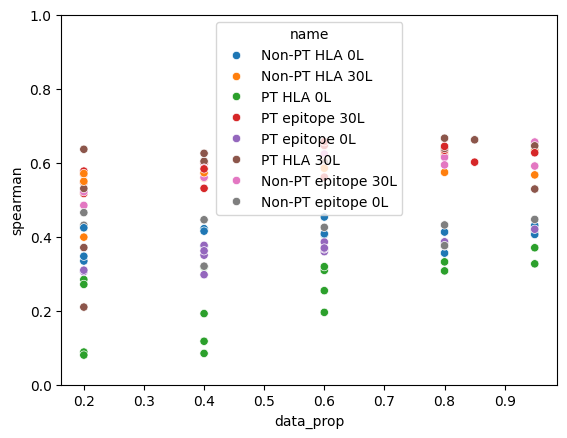

In [7]:
sns.scatterplot(data = evaluations_df[(evaluations_df['HLA'] == 'B0702')],
x = 'data_prop',
 y = 'spearman',
  hue = 'name', 
  alpha = 1)
plt.ylim([0,1])

In [8]:
evaluations_df = evaluations_df[evaluations_df['HLA'].isin(["A0201","B0702","A2601","B0801","B1801","A3001","A0101","A6801"])] #['A0201','B5701','A1101','A0301','B5101','A0206','B0702','B5101','B3501','A0101','A2402'])]

In [9]:
# keep only the needed columns and drop rows without a spearman
cols = ["HLA", "name", "path", "spearman"]
df = evaluations_df[cols].dropna(subset=["spearman"]).copy()

# top 3 per (HLA, name) by spearman
top3_df = (
    df.sort_values("spearman", ascending=False)
      .groupby(["HLA", "name"], as_index=False, group_keys=False)
      .head(3)
      .sort_values(["HLA", "name", "spearman", "path"], ascending=[True, True, False, True])
)

top3_df

,HLA,name,path,spearman
3198,A0101,Non-PT HLA 0L,/global/scratch/users/sergiomar10/losses/ESMCB...,-0.064130
4705,A0101,Non-PT HLA 0L,/global/scratch/users/sergiomar10/losses/ESMCB...,-0.074871
54,A0101,Non-PT HLA 0L,/global/scratch/users/sergiomar10/losses/ESMCB...,-0.083230
2109,A0101,Non-PT HLA 30L,/global/scratch/users/sergiomar10/losses/ESMCB...,0.659551
2894,A0101,Non-PT HLA 30L,/global/scratch/users/sergiomar10/losses/ESMCB...,0.643287
...,...,...,...,...
2852,B1801,PT epitope 0L,/global/scratch/users/sergiomar10/losses/ESMCB...,0.440559
5435,B1801,PT epitope 0L,/global/scratch/users/sergiomar10/losses/ESMCB...,0.426573
4917,B1801,PT epitope 30L,/global/scratch/users/sergiomar10/losses/ESMCB...,0.825175
3367,B1801,PT epitope 30L,/global/scratch/users/sergiomar10/losses/ESMCB...,0.797203


In [10]:
from pathlib import Path
from functools import reduce

# ---- helper: load a prediction file robustly and normalize columns ----
def _load_predictions(path):
    # 1) read
    p = str(path)
    if p.lower().endswith(".parquet"):
        df = pd.read_parquet(p)
    else:
        try:
            df = pd.read_csv(p, sep=None, engine="python")
        except Exception:
            df = pd.read_csv(p, sep="\t")

    # 2) guess identifier column
    id_candidates = [
        "epitope","Epitope","peptide","Peptide","sequence","Sequence",
        "seq","Seq","id","ID","Epitope_ID","epitope_id","uid","UID"
    ]
    id_col = next((c for c in id_candidates if c in df.columns), None)
    if id_col is None:
        # fall back to index
        df = df.reset_index().rename(columns={"index": "key"})
        id_col = "key"

    # 3) measured column
    measured_col = "measured" if "measured" in df.columns else None

    # 4) prediction column
    pred_candidates = [
        "prediction","pred","predicted","predictions","score","y_pred",
        "affinity_pred","pred_affinity","predicted_affinity",
        "logit","binding_pred","ESMCBA_prediction","MHCflurry_prediction","affinity"
    ]
    pred_col = next((c for c in pred_candidates if c in df.columns and c != measured_col), None)
    if pred_col is None:
        raise ValueError(f"No prediction column found in {path}. "
                         f"Looked for: {pred_candidates}")

    # 5) keep only needed cols and average duplicates on ID
    keep = [id_col, pred_col] + ([measured_col] if measured_col else [])
    d = df.loc[:, keep].copy()
    num_cols = [c for c in d.columns if c != id_col]
    d = d.groupby(id_col, as_index=False)[num_cols].mean()

    # 6) standardize names
    ren = {id_col: "key", pred_col: "pred"}
    if measured_col:
        ren[measured_col] = "measured"
    d = d.rename(columns=ren)

    return d  # columns: key, pred, [measured]

# ---------- main logic ----------
# expects top3_df with columns: HLA, name, path
assert {"HLA","name","path"}.issubset(top3_df.columns)

corr_by_hla_name = {}      # {(HLA, name): pandas.DataFrame corr-matrix across that group's paths}
path_vs_measured_rows = [] # list of dicts for per-path Spearman vs measured
load_errors = []

for (hla, nm), sub in top3_df.groupby(["HLA", "name"], sort=False):
    # load each path in this group
    matrices = []  # each is a 2-col df: key + one prediction column named by file
    pred_col_names = []  # keep original identity
    for path in sub["path"]:
        try:
            d = _load_predictions(path)
        except Exception as e:
            load_errors.append({"HLA": hla, "name": nm, "path": path, "error": str(e)})
            continue

        # rename pred to a unique column per path
        col_name = Path(str(path)).name  # short readable label
        pred_col_names.append((path, col_name))
        matrices.append(d[["key", "pred"]].rename(columns={"pred": col_name}))

        # per-path spearman vs measured
        if "measured" in d.columns:
            v = d[["pred", "measured"]].dropna()
            if len(v) >= 2:
                coef, pval = spearmanr(v["pred"], v["measured"])
                n = len(v)
            else:
                coef, pval, n = np.nan, np.nan, len(v)
        else:
            coef, pval, n = np.nan, np.nan, np.nan

        path_vs_measured_rows.append({
            "HLA": hla,
            "name": nm,
            "path": path,
            "spearman_vs_measured": float(coef) if pd.notna(coef) else np.nan,
            "pval": float(pval) if pd.notna(pval) else np.nan,
            "n": int(n) if pd.notna(n) else np.nan
        })

    # pairwise Spearman across all paths in this (HLA, name) group
    if len(matrices) >= 2:
        merged = reduce(lambda L, R: pd.merge(L, R, on="key", how="inner"), matrices)
        pred_cols = [c for c in merged.columns if c != "key"]
        if len(pred_cols) >= 2:
            corr = merged[pred_cols].corr(method="spearman")
            corr_by_hla_name[(hla, nm)] = corr

# tidy per-path results
path_vs_measured_df = (
    pd.DataFrame(path_vs_measured_rows)
      .sort_values(["HLA","name","spearman_vs_measured"], ascending=[True, True, False])
      .reset_index(drop=True)
)

# Examples of how to use the outputs:
# 1) correlation matrix for a specific (HLA, name):
# corr_by_hla_name.get(("HLA-A0201", "ESMCBA"))
#
# 2) per-path Spearman vs measured (with N and p-value):
# path_vs_measured_df
#
# 3) any load errors:
# pd.DataFrame(load_errors)


/tmp/ipykernel_3502389/3771656880.py:230: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


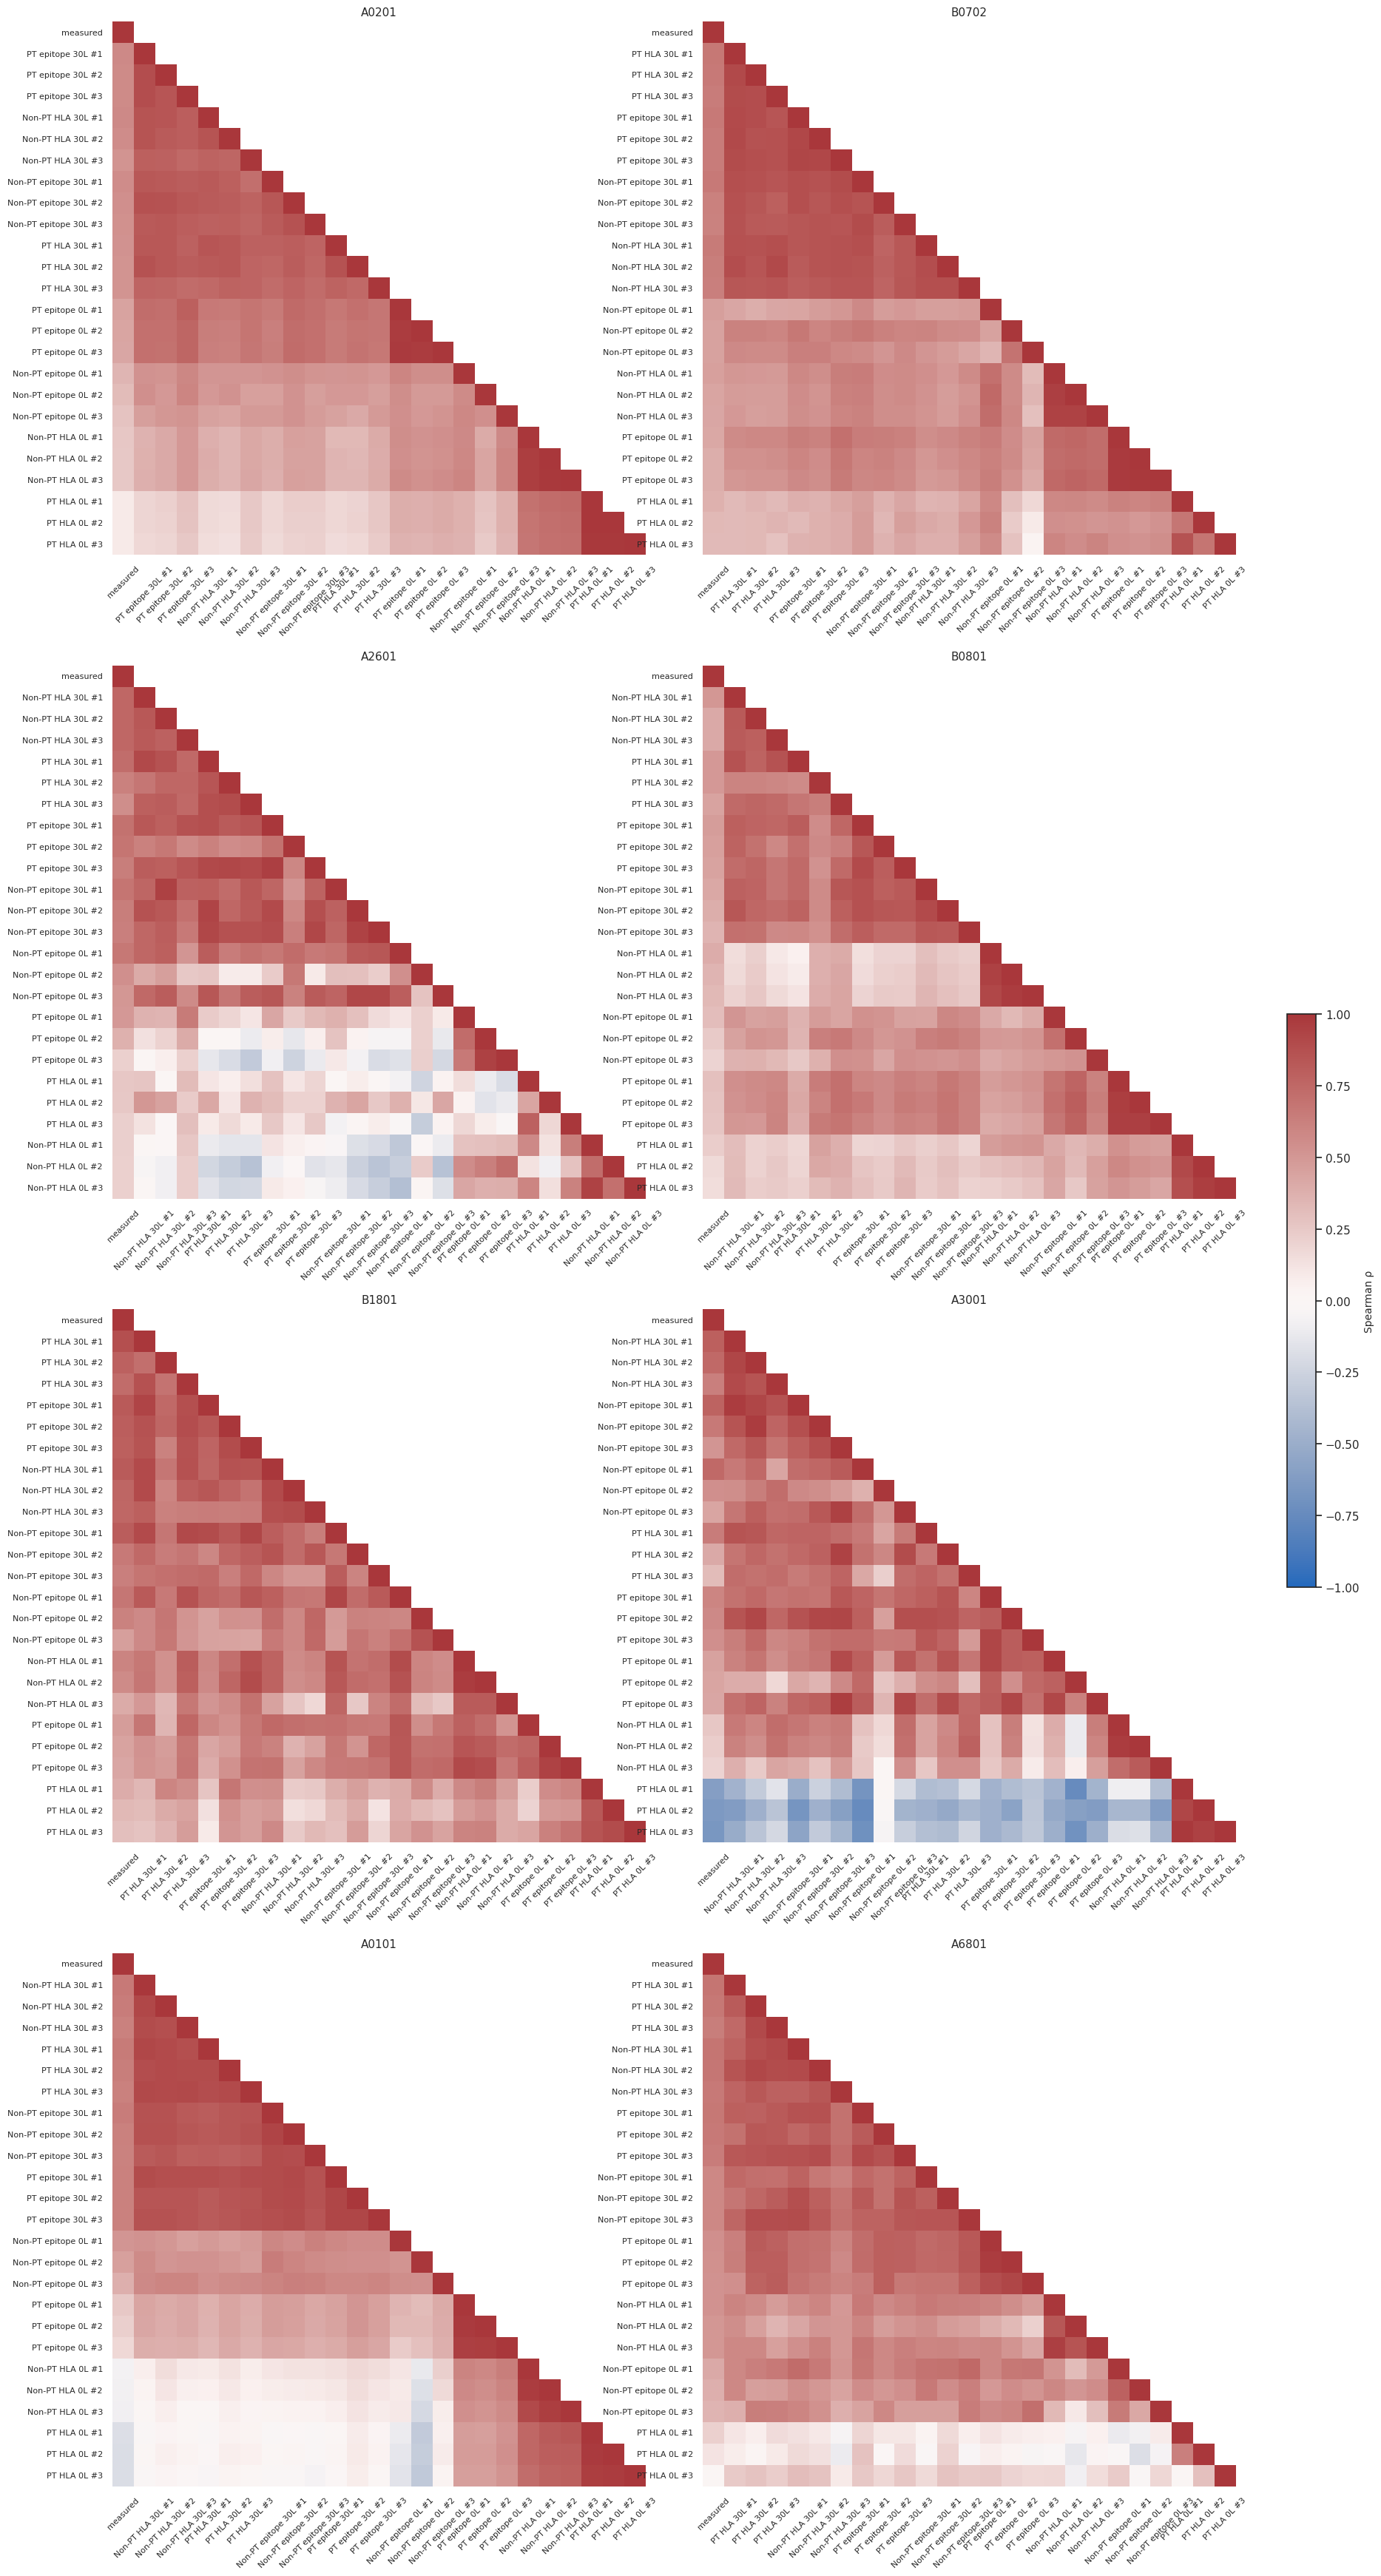

In [11]:
from functools import reduce

# ---- loader (same as before, returns columns: key, pred, [measured]) ----
def _load_predictions(path):
    p = str(path)
    if p.lower().endswith(".parquet"):
        df = pd.read_parquet(p)
    else:
        try:
            df = pd.read_csv(p, sep=None, engine="python")
        except Exception:
            df = pd.read_csv(p, sep="\t")

    id_candidates = [
        "epitope","Epitope","peptide","Peptide","sequence","Sequence",
        "seq","Seq","id","ID","Epitope_ID","epitope_id","uid","UID"
    ]
    id_col = next((c for c in id_candidates if c in df.columns), None)
    if id_col is None:
        df = df.reset_index().rename(columns={"index": "key"})
        id_col = "key"

    measured_col = "measured" if "measured" in df.columns else None
    pred_candidates = [
        "prediction","pred","predicted","predictions","score","y_pred",
        "affinity_pred","pred_affinity","predicted_affinity","logit",
        "binding_pred","ESMCBA_prediction","MHCflurry_prediction","affinity"
    ]
    pred_col = next((c for c in pred_candidates if c in df.columns and c != measured_col), None)
    if pred_col is None:
        raise ValueError(f"No prediction column found in file.")

    keep = [id_col, pred_col] + ([measured_col] if measured_col else [])
    d = df.loc[:, keep].copy()
    num_cols = [c for c in d.columns if c != id_col]
    d = d.groupby(id_col, as_index=False)[num_cols].mean()

    ren = {id_col: "key", pred_col: "pred"}
    if measured_col:
        ren[measured_col] = "measured"
    d = d.rename(columns=ren)
    return d  # key, pred, [measured]

# ---------- build wide table per HLA with 3 reps per name + measured ----------
def build_wide_by_hla_with_reps(top3_df):
    """
    Returns:
      wide_by_hla: {HLA: df with columns ['key', '<name> #1', '<name> #2', '<name> #3', ..., 'measured']}
      corr_by_hla: {HLA: Spearman correlation matrix across all columns except 'key'}
    """
    assert {"HLA","name","path","spearman"}.issubset(top3_df.columns)
    wide_by_hla = {}
    corr_by_hla  = {}

    for hla, sub_hla in top3_df.groupby("HLA", sort=False):
        cols = []
        measured_sources = []

        # enforce exactly the top 3 per name by spearman (in case top3_df wasn't filtered yet)
        for nm, sub_nm in (sub_hla.sort_values("spearman", ascending=False)
                                     .groupby("name", sort=False)):
            picks = list(sub_nm["path"])[:3]
            if len(picks) < 3:
                print(f"[WARN] {hla} | {nm} has {len(picks)} paths, expected 3.")

            for j, path in enumerate(picks, start=1):
                d = _load_predictions(path)
                cols.append(d[["key","pred"]].rename(columns={"pred": f"{nm} #{j}"}))
                if "measured" in d.columns:
                    measured_sources.append(d[["key","measured"]].copy())

        if not cols:
            continue

        wide = reduce(lambda L,R: pd.merge(L, R, on="key", how="outer"), cols)

        # unify measured from all sources by coalescing left to right
        if measured_sources:
            ms = [m.rename(columns={"measured": f"m{i}"}) for i, m in enumerate(measured_sources)]
            mmerge = reduce(lambda L,R: pd.merge(L, R, on="key", how="outer"), ms)
            # coalesce to a single measured column (take first non-NA)
            mcols = [c for c in mmerge.columns if c != "key"]
            mmerge["measured"] = mmerge[mcols].bfill(axis=1).iloc[:, 0]
            wide = wide.merge(mmerge[["key","measured"]], on="key", how="left")

        wide_by_hla[hla] = wide

        # correlation (pairwise complete obs), include measured if present
        pred_cols = [c for c in wide.columns if c != "key"]
        corr_by_hla[hla] = wide[pred_cols].corr(method="spearman")

    return wide_by_hla, corr_by_hla

wide_by_hla, corr_by_hla = build_wide_by_hla_with_reps(top3_df)

def plot_corr_for_hla_half(corr_by_hla, hla, annotate=False, figsize=7, half="upper"):
    """
    half: "upper" to mask upper triangle, "lower" to mask lower triangle.
    """
    if hla not in corr_by_hla:
        print(f"No matrix for {hla}")
        return

    corr = corr_by_hla[hla].copy()

    # put measured first if present
    cols = list(corr.columns)
    if "measured" in cols:
        cols = ["measured"] + [c for c in cols if c != "measured"]
        corr = corr.loc[cols, cols]

    # build mask
    n = corr.shape[0]
    mask = np.zeros_like(corr, dtype=bool)
    if half == "upper":
        mask[np.triu_indices(n, k=1)] = True   # mask above diagonal
    elif half == "lower":
        mask[np.tril_indices(n, k=1)] = True   # mask below diagonal

    sns.set(style="white")
    plt.figure(figsize=(figsize, figsize))
    ax = sns.heatmap(
        corr,
        mask=mask,
        vmin=-1, vmax=1, center=0,
        cmap="vlag",
        square=True,
        cbar=True,
        annot=annotate, fmt=".2f" if annotate else "",
        linewidths=0
    )
    ax.set_title(f"HLA-{hla}", fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="center", fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
    plt.tight_layout()
    plt.show()


def _order_cols_measured_first_and_group_reps(corr):
    cols = list(corr.columns)
    # put measured first if present
    if "measured" in cols:
        cols.remove("measured")
        ordered = ["measured"]
    else:
        ordered = []

    # group base names and sort reps as #1,#2,#3
    # base name is everything before " #<num>"
    base2reps = {}
    for c in cols:
        m = re.match(r"^(.*)\s+#(\d+)$", c)
        if m:
            base, rep = m.group(1), int(m.group(2))
        else:
            base, rep = c, 999  # if not a replicate label, push to end
        base2reps.setdefault(base, []).append((rep, c))

    # keep stable order by the first occurrence in cols
    seen_base = []
    for c in cols:
        base = re.match(r"^(.*)\s+#\d+$", c)
        base = base.group(1) if base else c
        if base not in seen_base:
            seen_base.append(base)

    for base in seen_base:
        reps = sorted(base2reps[base], key=lambda x: x[0])
        ordered.extend([c for _, c in reps])

    # ensure all are present and unique
    ordered = [c for c in ordered if c in corr.columns]
    return ordered

def plot_hla_grid_lower_triangle(corr_by_hla, hlas, ncols=2, figsize_per_panel=4.0,
                                 annotate=False, save_path=None, dpi=300):
    """
    corr_by_hla: dict {HLA: corr-matrix DataFrame}
    hlas: list of HLA strings to plot
    """
    sns.set(style="white")
    hlas = [h for h in hlas if h in corr_by_hla]
    if not hlas:
        print("No matching HLAs to plot.")
        return

    n = len(hlas)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(20,35),
                             squeeze=False)

    vmin, vmax = -1.0, 1.0
    norm = Normalize(vmin=vmin, vmax=vmax)
    mappable = ScalarMappable(norm=norm, cmap="vlag")
    mappable.set_array([])

    k = 0
    for r in range(nrows):
        for c in range(ncols):
            ax = axes[r][c]
            if k >= n:
                ax.axis("off")
                continue

            hla = hlas[k]
            corr = corr_by_hla[hla].copy()
            # reorder columns: measured first, then groups of name #1..#3
            ordered = _order_cols_measured_first_and_group_reps(corr)
            corr = corr.loc[ordered, ordered]

            # mask upper triangle (keep diagonal)
            m = np.zeros_like(corr, dtype=bool)
            m[np.triu_indices_from(m, k=1)] = True

            sns.heatmap(corr, mask=m, cmap="vlag", vmin=vmin, vmax=vmax, center=0,
                        square=True, cbar=False, ax=ax,
                        annot=annotate, fmt=".2f" if annotate else "",
                        linewidths=0)

            ax.set_title(hla, fontsize=11)
            ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="center", fontsize=8)
            ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
            k += 1

    # shared colorbar
    cbar = fig.colorbar(mappable, ax=axes.ravel().tolist(),
                        fraction=0.025, pad=-0.2)
    cbar.set_label("Spearman ρ", fontsize=10)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.show()

import math
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import re

target_hlas = ["A0201","B0702","A2601","B0801","B1801","A3001","A0101","A6801"]
plot_hla_grid_lower_triangle(corr_by_hla, target_hlas, ncols=2, figsize_per_panel=2.2,
                             annotate=False, save_path="corr_name_reps_grid.png", dpi=300)


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, ttest_ind
import math
import re
from functools import reduce

# ============================================================================
# STEP 1: Load and filter to ensure exactly 3 models per regime
# ============================================================================

def ensure_3_reps_per_regime(top3_df):
    """
    Ensure we have exactly 3 replicates per regime (name) for each HLA.
    Takes top 3 by spearman correlation.
    
    Returns: filtered dataframe with exactly 3 rows per (HLA, name) combination
    """
    print("Original shape:", top3_df.shape)
    print("\nChecking replicates per regime per HLA:")
    
    filtered_rows = []
    
    for hla, hla_group in top3_df.groupby("HLA", sort=False):
        for name, name_group in hla_group.groupby("name", sort=False):
            # Sort by spearman (descending) and take top 3
            top_3 = name_group.sort_values("spearman", ascending=False).head(3)
            
            if len(top_3) < 3:
                print(f"  WARNING: {hla} | {name} has only {len(top_3)} models (need 3)")
            elif len(top_3) == 3:
                print(f"  ✓ {hla} | {name} has 3 models")
            
            filtered_rows.append(top_3)
    
    result = pd.concat(filtered_rows, ignore_index=True)
    print(f"\nFiltered shape: {result.shape}")
    
    # Verify the counts
    print("\nVerification - counts per (HLA, name):")
    counts = result.groupby(["HLA", "name"]).size()
    print(counts)
    print(f"\nAll have exactly 3? {(counts == 3).all()}")
    
    return result


# ============================================================================
# STEP 2: Load the data
# ============================================================================

# Assuming top3_df exists in your environment with columns: HLA, name, path, spearman
# If you need to load it from a file, uncomment and modify:
# top3_df = pd.read_csv("path_to_your_top3_file.csv")

# Filter to ensure exactly 3 replicates per regime
top3_df_filtered = ensure_3_reps_per_regime(top3_df)


# ============================================================================
# STEP 3: Loader function
# ============================================================================

def _load_predictions(path):
    """Load predictions from parquet or CSV file."""
    p = str(path)
    if p.lower().endswith(".parquet"):
        df = pd.read_parquet(p)
    else:
        try:
            df = pd.read_csv(p, sep=None, engine="python")
        except Exception:
            df = pd.read_csv(p, sep="\t")

    id_candidates = [
        "epitope","Epitope","peptide","Peptide","sequence","Sequence",
        "seq","Seq","id","ID","Epitope_ID","epitope_id","uid","UID"
    ]
    id_col = next((c for c in id_candidates if c in df.columns), None)
    if id_col is None:
        df = df.reset_index().rename(columns={"index": "key"})
        id_col = "key"

    measured_col = "measured" if "measured" in df.columns else None
    pred_candidates = [
        "prediction","pred","predicted","predictions","score","y_pred",
        "affinity_pred","pred_affinity","predicted_affinity","logit",
        "binding_pred","ESMCBA_prediction","MHCflurry_prediction","affinity"
    ]
    pred_col = next((c for c in pred_candidates if c in df.columns and c != measured_col), None)
    if pred_col is None:
        raise ValueError(f"No prediction column found in file.")

    keep = [id_col, pred_col] + ([measured_col] if measured_col else [])
    d = df.loc[:, keep].copy()
    num_cols = [c for c in d.columns if c != id_col]
    d = d.groupby(id_col, as_index=False)[num_cols].mean()

    ren = {id_col: "key", pred_col: "pred"}
    if measured_col:
        ren[measured_col] = "measured"
    d = d.rename(columns=ren)
    return d  # key, pred, [measured]


# ============================================================================
# STEP 4: Build wide table with replicates
# ============================================================================

def build_wide_by_hla_with_reps(top3_df):
    """
    Returns:
      wide_by_hla: {HLA: df with columns ['key', '<name> #1', '<name> #2', '<name> #3', ..., 'measured']}
      corr_by_hla: {HLA: Spearman correlation matrix across all columns except 'key'}
    """
    assert {"HLA","name","path","spearman"}.issubset(top3_df.columns)
    wide_by_hla = {}
    corr_by_hla  = {}

    for hla, sub_hla in top3_df.groupby("HLA", sort=False):
        cols = []
        measured_sources = []

        # Process each regime (name)
        for nm, sub_nm in sub_hla.groupby("name", sort=False):
            # Sort by spearman and take paths (should already be filtered to 3)
            picks = list(sub_nm.sort_values("spearman", ascending=False)["path"])
            
            if len(picks) != 3:
                print(f"[WARN] {hla} | {nm} has {len(picks)} paths, expected exactly 3.")

            for j, path in enumerate(picks, start=1):
                d = _load_predictions(path)
                cols.append(d[["key","pred"]].rename(columns={"pred": f"{nm} #{j}"}))
                if "measured" in d.columns:
                    measured_sources.append(d[["key","measured"]].copy())

        if not cols:
            continue

        wide = reduce(lambda L,R: pd.merge(L, R, on="key", how="outer"), cols)

        # unify measured from all sources by coalescing left to right
        if measured_sources:
            ms = [m.rename(columns={"measured": f"m{i}"}) for i, m in enumerate(measured_sources)]
            mmerge = reduce(lambda L,R: pd.merge(L, R, on="key", how="outer"), ms)
            # coalesce to a single measured column (take first non-NA)
            mcols = [c for c in mmerge.columns if c != "key"]
            mmerge["measured"] = mmerge[mcols].bfill(axis=1).iloc[:, 0]
            wide = wide.merge(mmerge[["key","measured"]], on="key", how="left")

        wide_by_hla[hla] = wide

        # correlation (pairwise complete obs), include measured if present
        pred_cols = [c for c in wide.columns if c != "key"]
        corr_by_hla[hla] = wide[pred_cols].corr(method="spearman")
        
        print(f"✓ Built wide table for {hla}: {wide.shape[0]} peptides, {len(pred_cols)} columns")

    return wide_by_hla, corr_by_hla


print("\n" + "="*80)
print("REBUILDING WIDE TABLES WITH 3 REPLICATES PER REGIME")
print("="*80 + "\n")

wide_by_hla, corr_by_hla = build_wide_by_hla_with_reps(top3_df_filtered)

print("\n" + "="*80)
print(f"Successfully built wide tables for {len(wide_by_hla)} HLAs")
print("="*80)

# Add diagnostic: check data overlap
print("\n" + "="*80)
print("DIAGNOSING DATA OVERLAP")
print("="*80 + "\n")

for hla, wide_df in wide_by_hla.items():
    print(f"\n{hla}:")
    print(f"  Total peptides: {len(wide_df)}")
    if "measured" in wide_df.columns:
        n_measured = wide_df['measured'].notna().sum()
        print(f"  Peptides with measured values: {n_measured}")
        
        model_cols = [c for c in wide_df.columns if c not in ['key', 'measured']]
        print(f"  Total model columns: {len(model_cols)}")
        
        # Check overlap for each model
        overlaps = {}
        for col in model_cols:
            both_present = (wide_df['measured'].notna() & wide_df[col].notna()).sum()
            overlaps[col] = both_present
        
        # Show summary
        overlap_counts = pd.Series(overlaps)
        print(f"  Models with ≥10 overlapping peptides: {(overlap_counts >= 10).sum()}/{len(model_cols)}")
        print(f"  Models with ≥5 overlapping peptides: {(overlap_counts >= 5).sum()}/{len(model_cols)}")
        print(f"  Models with ≥1 overlapping peptides: {(overlap_counts >= 1).sum()}/{len(model_cols)}")
        print(f"  Models with 0 overlapping peptides: {(overlap_counts == 0).sum()}/{len(model_cols)}")
    else:
        print(f"  No measured values available")

print("\n" + "="*80)


# ============================================================================
# STEP 5: Run comparison analysis
# ============================================================================

def extract_base_name(col_name):
    """Extract base model name from replicate column like 'ESMCBA #1' -> 'ESMCBA'"""
    match = re.match(r"^(.*)\s+#\d+$", col_name)
    return match.group(1) if match else col_name


def compare_model_regimes_bootstrap(wide_by_hla, n_bootstrap=1000):
    """
    Compare model regimes using bootstrap resampling on peptide-level predictions.
    This gives us error bars even when only 1 replicate has data!
    """
    comparison_results = {}
    
    for hla, wide_df in wide_by_hla.items():
        if "measured" not in wide_df.columns:
            continue
        
        model_cols = [c for c in wide_df.columns if c not in ['key', 'measured']]
        
        # Group replicates by base model name
        regime_to_reps = {}
        for col in model_cols:
            base = extract_base_name(col)
            regime_to_reps.setdefault(base, []).append(col)
        
        # Keep only regimes with exactly 3 replicates loaded
        regime_to_reps = {k: v for k, v in regime_to_reps.items() if len(v) == 3}
        
        if len(regime_to_reps) < 2:
            continue
        
        df_clean = wide_df.dropna(subset=['measured'])
        
        # Bootstrap correlations for each regime
        regime_bootstrap_corrs = {}
        regime_mean_corrs = {}
        
        for regime, rep_cols in regime_to_reps.items():
            # Combine all replicates' data into one pool for bootstrapping
            all_pairs = []
            
            for col in rep_cols:
                valid_mask = df_clean[col].notna()
                if valid_mask.sum() >= 1:
                    pairs = list(zip(
                        df_clean.loc[valid_mask, col].values,
                        df_clean.loc[valid_mask, 'measured'].values
                    ))
                    all_pairs.extend(pairs)
            
            if len(all_pairs) < 5:  # Need at least some data
                print(f"  SKIP: {hla} | {regime} has only {len(all_pairs)} peptide pairs total")
                continue
            
            # Bootstrap resample to get distribution of correlations
            bootstrap_corrs = []
            for _ in range(n_bootstrap):
                # Sample with replacement
                sample_indices = np.random.choice(len(all_pairs), size=len(all_pairs), replace=True)
                sample_pairs = [all_pairs[i] for i in sample_indices]
                
                pred_boot = [p[0] for p in sample_pairs]
                meas_boot = [p[1] for p in sample_pairs]
                
                corr, _ = spearmanr(pred_boot, meas_boot)
                bootstrap_corrs.append(corr)
            
            regime_bootstrap_corrs[regime] = np.array(bootstrap_corrs)
            regime_mean_corrs[regime] = np.mean(bootstrap_corrs)
            
            print(f"  ✓ {hla} | {regime}: ρ = {np.mean(bootstrap_corrs):.4f} ± {np.std(bootstrap_corrs):.4f} (from {len(all_pairs)} peptide pairs)")
        
        if len(regime_bootstrap_corrs) < 2:
            continue
        
        # Find best regime by mean
        best_name = max(regime_mean_corrs.items(), key=lambda x: x[1])[0]
        best_corrs = regime_bootstrap_corrs[best_name]
        
        # Compare to others
        other_comparisons = []
        for regime_name in sorted(regime_mean_corrs.keys(), 
                                  key=lambda x: regime_mean_corrs[x], reverse=True):
            if regime_name == best_name:
                continue
            
            other_corrs = regime_bootstrap_corrs[regime_name]
            
            # Two-sample t-test on bootstrap distributions
            t_stat, p_value = ttest_ind(best_corrs, other_corrs, alternative='greater')
            
            other_comparisons.append({
                'regime': regime_name,
                'bootstrap_corrs': other_corrs,
                'mean_corr': np.mean(other_corrs),
                'se': np.std(other_corrs),  # Bootstrap SE
                'diff': np.mean(best_corrs) - np.mean(other_corrs),
                't_statistic': t_stat,
                'p_value': p_value,
                'significant': p_value < 0.05
            })
        
        comparison_results[hla] = {
            'best_regime': best_name,
            'bootstrap_corrs': best_corrs,
            'best_corr': np.mean(best_corrs),
            'best_se': np.std(best_corrs),  # Bootstrap SE
            'other_regimes': other_comparisons
        }
    
    return comparison_results


print("\n" + "="*80)
print("RUNNING BOOTSTRAP REGIME COMPARISON (1000 iterations)")
print("="*80 + "\n")

comparison_results = compare_model_regimes_bootstrap(wide_by_hla, n_bootstrap=1000)

print(f"\n{'='*80}")
print(f"Bootstrap comparison results for {len(comparison_results)} HLAs")
print(f"{'='*80}")
for hla, result in comparison_results.items():
    print(f"\n{hla}:")
    print(f"  Best regime: {result['best_regime']} (ρ = {result['best_corr']:.4f} ± {result['best_se']:.4f})")
    print(f"  Compared against {len(result['other_regimes'])} other regimes:")
    for other in result['other_regimes']:
        sig_marker = " ***" if other['significant'] else ""
        print(f"    - {other['regime']}: ρ = {other['mean_corr']:.4f} ± {other['se']:.4f}{sig_marker}")


# ============================================================================
# STEP 6: Plot the results
# ============================================================================


Original shape: (192, 4)

Checking replicates per regime per HLA:
  ✓ A0101 | Non-PT HLA 0L has 3 models
  ✓ A0101 | Non-PT HLA 30L has 3 models
  ✓ A0101 | Non-PT epitope 0L has 3 models
  ✓ A0101 | Non-PT epitope 30L has 3 models
  ✓ A0101 | PT HLA 0L has 3 models
  ✓ A0101 | PT HLA 30L has 3 models
  ✓ A0101 | PT epitope 0L has 3 models
  ✓ A0101 | PT epitope 30L has 3 models
  ✓ A0201 | Non-PT HLA 0L has 3 models
  ✓ A0201 | Non-PT HLA 30L has 3 models
  ✓ A0201 | Non-PT epitope 0L has 3 models
  ✓ A0201 | Non-PT epitope 30L has 3 models
  ✓ A0201 | PT HLA 0L has 3 models
  ✓ A0201 | PT HLA 30L has 3 models
  ✓ A0201 | PT epitope 0L has 3 models
  ✓ A0201 | PT epitope 30L has 3 models
  ✓ A2601 | Non-PT HLA 0L has 3 models
  ✓ A2601 | Non-PT HLA 30L has 3 models
  ✓ A2601 | Non-PT epitope 0L has 3 models
  ✓ A2601 | Non-PT epitope 30L has 3 models
  ✓ A2601 | PT HLA 0L has 3 models
  ✓ A2601 | PT HLA 30L has 3 models
  ✓ A2601 | PT epitope 0L has 3 models
  ✓ A2601 | PT epitope 30L

In [15]:
rep_stats_pooled = pd.read_csv('../../data/regimes.csv')

In [16]:

# Helper functions
def IQR(x): 
    return x.quantile(0.75) - x.quantile(0.25)

def coerce_prop(x):
    """Convert training_data to numeric - keep as raw numbers if already numeric"""
    # If already numeric, return as-is
    if pd.api.types.is_numeric_dtype(x):
        return x
    
    # Otherwise convert from string/percentage format
    s = x.astype(str).str.rstrip('%')
    v = pd.to_numeric(s, errors='coerce')
    return v/100.0 if v.max() > 1 else v

def slope_ci(sub):
    """Calculate slope with confidence intervals"""
    x = coerce_prop(sub['training_data'])
    y = sub['mean']
    ok = (~x.isna()) & (~y.isna())
    
    if ok.sum() < 3 or x[ok].nunique() < 3:
        return pd.Series({
            'slope': np.nan, 'lo': np.nan, 'hi': np.nan, 
            'n_points': int(ok.sum()), 'r_squared': np.nan
        })
    
    X = sm.add_constant(x[ok].values)
    fit = sm.OLS(y[ok].values, X).fit()
    lo, hi = fit.conf_int(alpha=0.05)[1]
    
    return pd.Series({
        'slope': fit.params[1], 
        'lo': lo, 
        'hi': hi, 
        'n_points': int(ok.sum()),
        'r_squared': fit.rsquared
    })


[Bins] Bin edges: [ 500. 1000. 1500. 2000. 2500. 3550.]
[Bins] Bin centers: [ 750. 1250. 1750. 2250. 3025.]
[Bins] Coverage per bin: {Interval(499.999, 1000.0, closed='right'): 12, Interval(1000.0, 1500.0, closed='right'): 12, Interval(1500.0, 2000.0, closed='right'): 9, Interval(2000.0, 2500.0, closed='right'): 9, Interval(2500.0, 3550.0, closed='right'): 8}
[Panel E] Number of points per regime: {'Non-PT H 0L': 5, 'Non-PT H 30L': 5, 'PT E 0L': 5, 'PT E 30L': 5, 'PT H 0L': 5, 'PT H 30L': 5}
[Panel E] Number of points per regime: {'Non-PT H 0L': 5, 'Non-PT H 30L': 5, 'PT E 0L': 5, 'PT E 30L': 5, 'PT H 0L': 5, 'PT H 30L': 5}


/tmp/ipykernel_3502389/3634158807.py:127: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cov = pooled.dropna(subset=["size_bin"]).groupby("size_bin")["HLA"].nunique()
/tmp/ipykernel_3502389/3634158807.py:135: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["group_label","bin_center"])
/tmp/ipykernel_3502389/3634158807.py:147: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["group_label","bin_center"])
/tmp

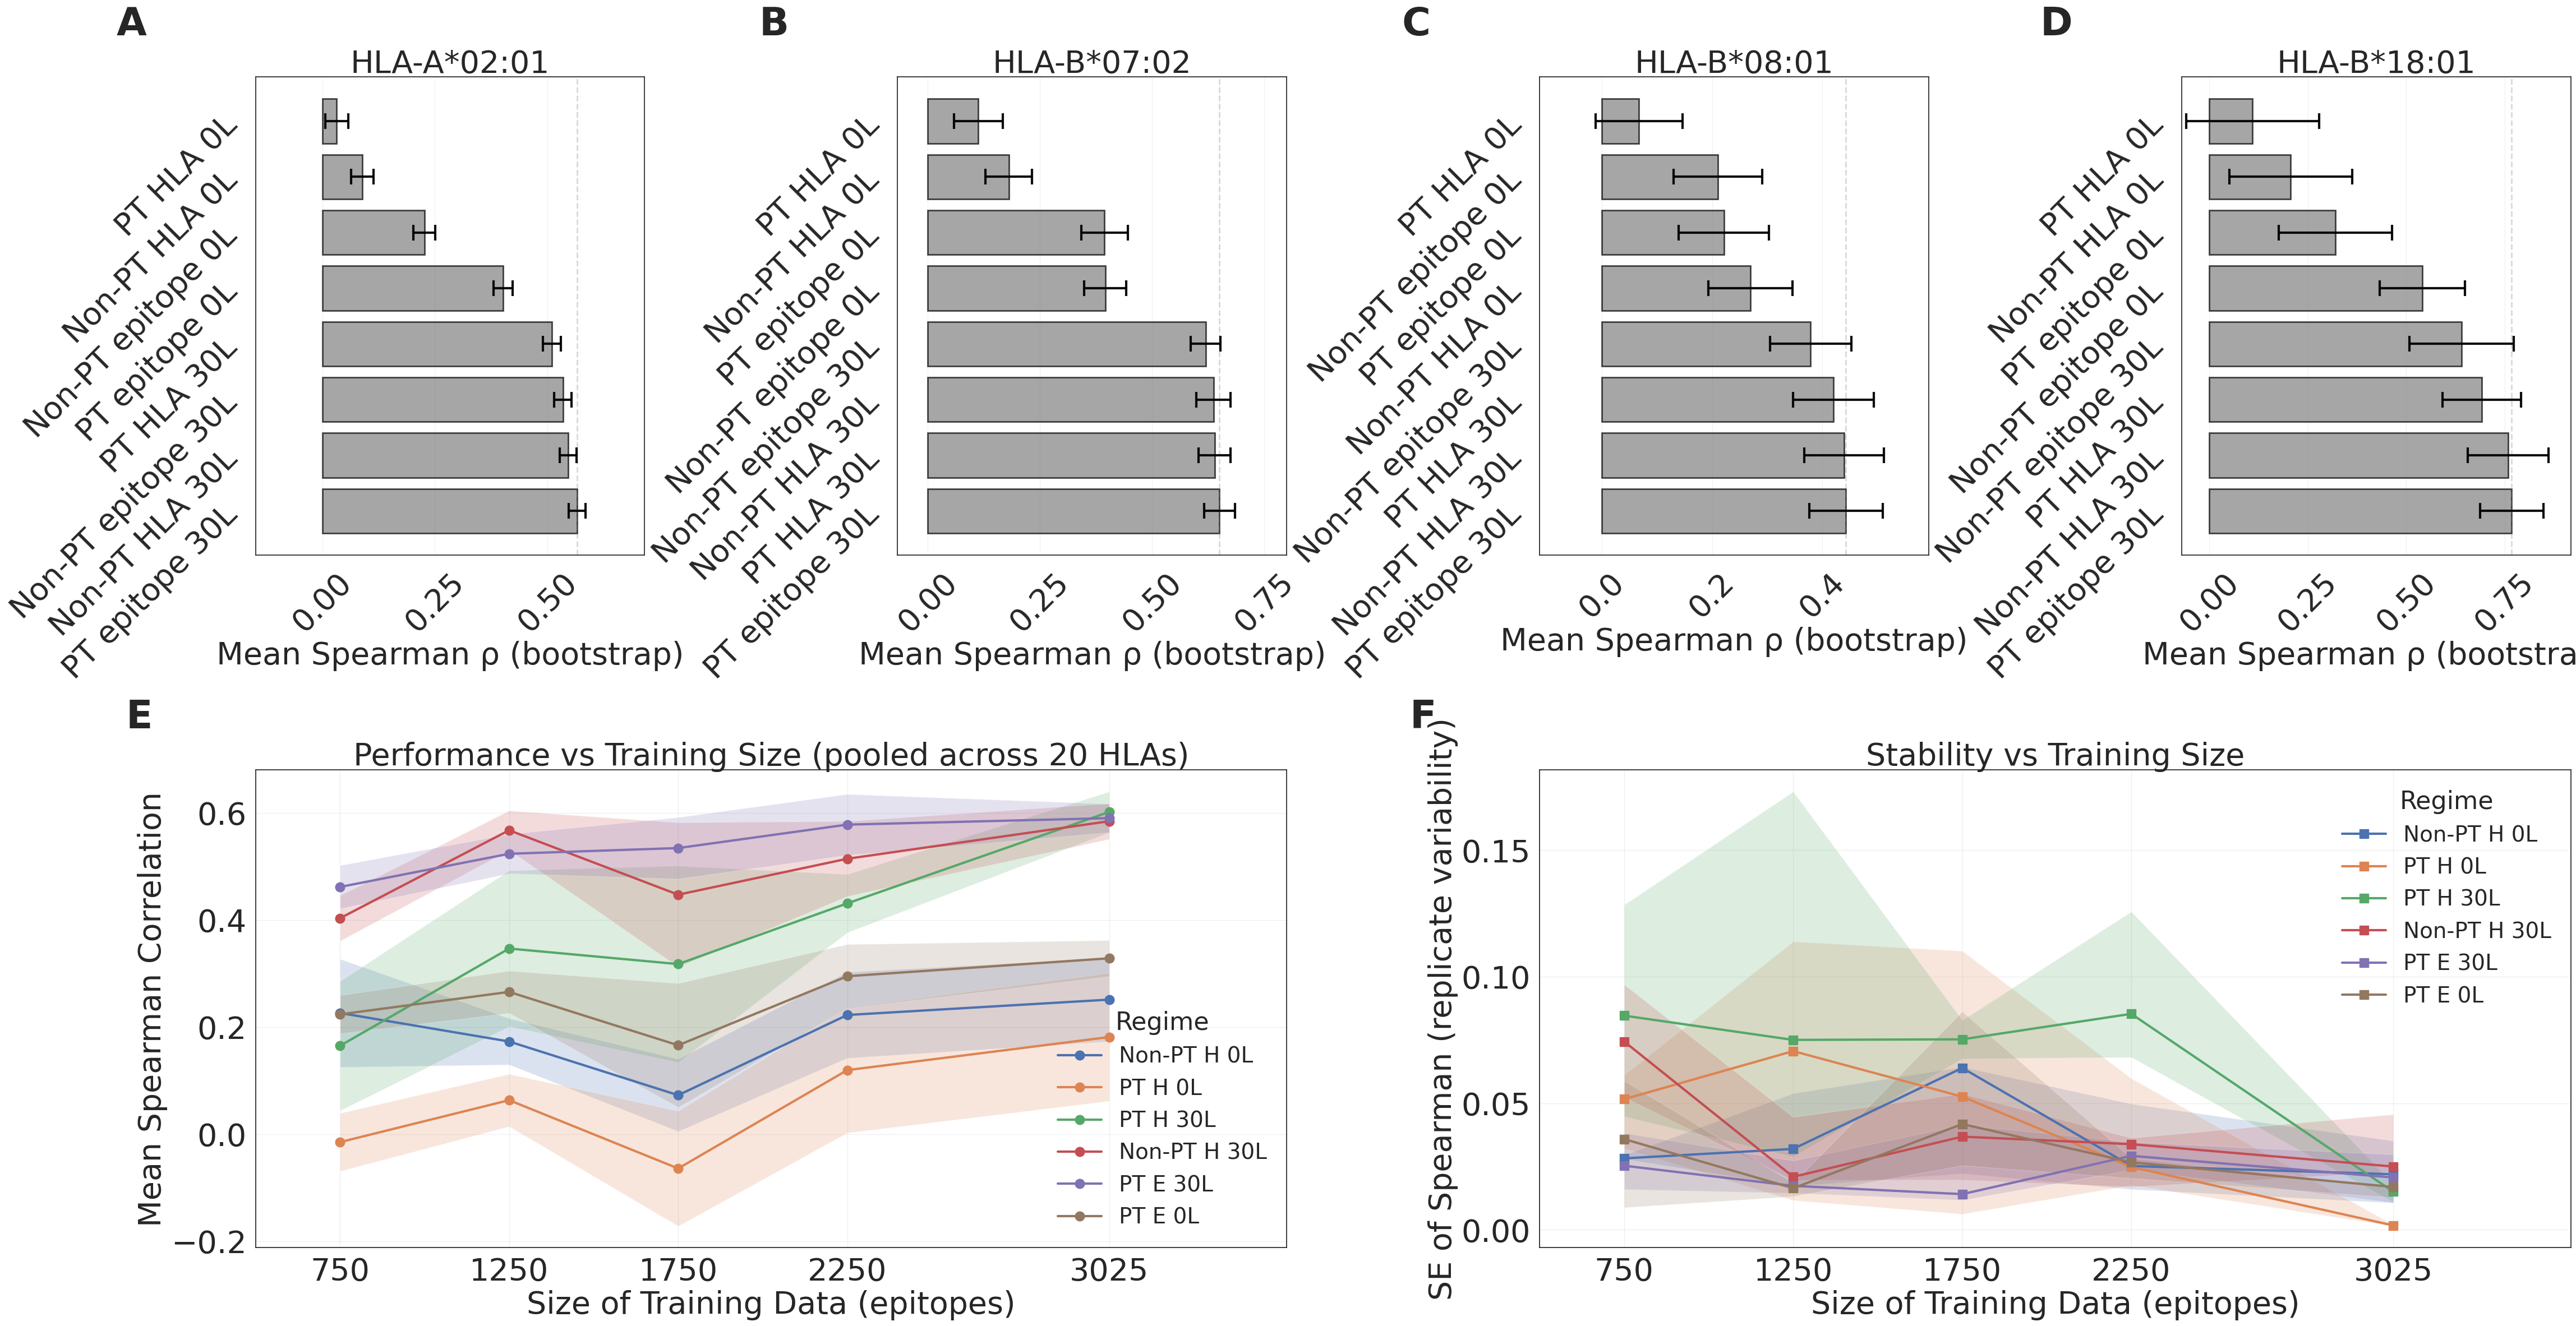

In [128]:
# Define color scheme
HIGHLIGHT_COLOR = '#808080'
GRAY_COLOR = '#808080'

# Create figure with custom layout - MUCH LARGER
fig = plt.figure(figsize=(48, 24))  # Increased from (36, 18)
gs = fig.add_gridspec(2, 4, height_ratios=[1, 1], hspace=0.45, wspace=0.65, 
                      left=0.12, right=0.98, top=0.95, bottom=0.08)  # More spacing

# ============================================================================
# ROW 1 (A): Four HLA comparison plots
# ============================================================================
target_hlas = sorted(["A0201", "B0702", "B0801", "B1801"])

for idx, hla in enumerate(target_hlas):
    ax = fig.add_subplot(gs[0, idx])
    
    if hla not in comparison_results:
        ax.text(0.5, 0.5, f"{hla}\nNo data available", 
               ha='center', va='center', transform=ax.transAxes, fontsize=40)
        ax.axis('off')
        continue
    
    data = comparison_results[hla]
    best_regime = data['best_regime']
    best_corr = data['best_corr']
    best_se = data['best_se']
    others = data['other_regimes']
    
    if not others:
        ax.text(0.5, 0.5, f"{hla}\nNo comparisons available", 
               ha='center', va='center', transform=ax.transAxes, fontsize=40)
        ax.axis('off')
        continue
    
    # Prepare data for plotting
    regime_names = [best_regime] + [o['regime'] for o in others]
    corrs = [best_corr] + [o['mean_corr'] for o in others]
    ses = [best_se] + [o['se'] for o in others]
    
    y_pos = np.arange(len(regime_names))
    
    # Color: only best model highlighted
    colors = [HIGHLIGHT_COLOR] + [GRAY_COLOR] * len(others)
    
    # Plot correlations
    bars = ax.barh(y_pos, corrs, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    
    # Add error bars for every model
    for i in range(len(corrs)):
        corr_val = corrs[i]
        se_val = ses[i]
        ax.errorbar(corr_val, i, xerr=se_val, fmt='none', 
                   ecolor='black', capsize=10, capthick=3, linewidth=3, alpha=0.95,
                   zorder=10)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(regime_names, fontsize=40)  # Increased to 40
    ax.set_xlabel('Mean Spearman ρ (bootstrap)', fontsize=40)  # Increased to 40
    hla_formatted = 'HLA-' + hla[0] + '*' + hla[1:3] + ':' + hla[3:]
    ax.set_title(f"{hla_formatted}", fontsize=40)  # Increased to 40
    
    # Adjust xlim
    ax.set_xlim([min(corrs) - 0.18, max(corrs) + 0.15])
    
    ax.axvline(best_corr, color=HIGHLIGHT_COLOR, linestyle='--', alpha=0.3, linewidth=2)
    ax.grid(axis='x', alpha=0.3, linewidth=0.8)
    ax.tick_params(axis='both', which='major', labelsize=40, pad=10, rotation = 45)  # Increased to 40 and more pad
    
    # Add panel label
    panel_label = chr(65 + idx)  # A, B, C, D
    ax.text(-0.28, 1.15, panel_label, transform=ax.transAxes,
            fontsize=50, va='top', ha='right', weight='bold')  # Increased to 50

# ============================================================================
# ROW 2: Pooled analysis plots
# ============================================================================

# Update font sizes - ALL TO 40
plt.rcParams.update({
    "font.size": 40,
    "axes.titlesize": 40,
    "axes.labelsize": 40,
    "xtick.labelsize": 40,
    "ytick.labelsize": 40,
    "legend.fontsize": 40,
    "figure.titlesize": 40,
})

# Prepare pooled data
target_hlas_pooled = rep_stats_pooled["HLA"].unique()
# rep_stats_pooled = rep_stats_pooled[rep_stats_pooled['std'] != 0]
pooled_data = rep_stats_pooled[rep_stats_pooled['HLA'].isin(target_hlas_pooled)].copy()

if pooled_data.empty:
    raise ValueError("No rows after filtering by target_hlas.")

pooled_data['training_data_numeric'] = coerce_prop(pooled_data['training_data'])
# --- Replace everything from "Create bins" through 'curve_stats' and the Panel E loop ---

# If your training sizes are already discrete (500, 1000, ..., 6000), don't bin;
# just use that numeric column directly. Otherwise keep your bins.
sizes = coerce_prop(rep_stats_pooled['training_data'])  # your helper
# ---------- Shared binning for Panels E and F ----------
# ================== Panels E & F with ADAPTIVE WIDE BINS ==================
import numpy as np
import pandas as pd

pooled = rep_stats_pooled.copy()  # do NOT drop zero-SD rows
# numeric size
numcol = "training_data_numeric" if "training_data_numeric" in pooled.columns else "training_data"
pooled["training_data_numeric"] = pd.to_numeric(pooled[numcol], errors="coerce")
pooled = pooled.dropna(subset=["training_data_numeric","mean","HLA","group_label"]).copy()

LOWER   = 500               # start from 500
MIN_HLAS_PER_BIN = 2        # coverage target per bin (across all regimes)

# Manual bins with bigger last two bins
EDGES = np.array([500, 1000, 1500, 2000, 2500, 3550], dtype=float)
CENTERS = (EDGES[:-1] + EDGES[1:]) / 2.0

print(f"[Bins] Bin edges: {EDGES}")
print(f"[Bins] Bin centers: {CENTERS}")

# Check coverage
pooled["size_bin"] = pd.cut(pooled["training_data_numeric"], EDGES, include_lowest=True, right=True)
cov = pooled.dropna(subset=["size_bin"]).groupby("size_bin")["HLA"].nunique()
print(f"[Bins] Coverage per bin: {cov.to_dict()}")

pooled["bin_center"] = pooled["size_bin"].apply(lambda iv: iv.mid if pd.notna(iv) else np.nan)
pooled["replicate_se"] = pooled["std"] / np.sqrt(pooled["n_reps"])

# -------- Panel E: across-HLA mean & SE across HLAs (same bins) --------
perf_agg_raw = (pooled.dropna(subset=["bin_center"])
                .groupby(["group_label","bin_center"])
                .agg(n_hlas=("HLA","nunique"),
                     mean=("mean","mean"),
                     sd=("mean","std"))
                .reset_index())

# Relax the requirement to just 1 HLA if needed
perf_agg = perf_agg_raw.loc[perf_agg_raw["n_hlas"] >= 1].copy()
perf_agg["se"] = perf_agg["sd"] / np.sqrt(perf_agg["n_hlas"].clip(lower=1))

print(f"[Panel E] Number of points per regime: {perf_agg.groupby('group_label').size().to_dict()}")
perf_agg_raw = (pooled.dropna(subset=["bin_center"])
                .groupby(["group_label","bin_center"])
                .agg(n_hlas=("HLA","nunique"),
                     mean=("mean","mean"),
                     sd=("mean","std"))
                .reset_index())

# Relax the requirement to just 1 HLA if needed
perf_agg = perf_agg_raw.loc[perf_agg_raw["n_hlas"] >= 1].copy()
perf_agg["se"] = perf_agg["sd"] / np.sqrt(perf_agg["n_hlas"].clip(lower=1))

print(f"[Panel E] Number of points per regime: {perf_agg.groupby('group_label').size().to_dict()}")
perf_agg_raw = (pooled.dropna(subset=["bin_center"])
                .groupby(["group_label","bin_center"])
                .agg(n_hlas=("HLA","nunique"),
                     mean=("mean","mean"),
                     sd=("mean","std"))
                .reset_index())

perf_agg = perf_agg_raw.loc[perf_agg_raw["n_hlas"] >= 2].copy()
if perf_agg.empty:
    # relax if absolutely needed
    perf_agg = perf_agg_raw.loc[perf_agg_raw["n_hlas"] >= 1].copy()
perf_agg["se"] = perf_agg["sd"] / np.sqrt(perf_agg["n_hlas"].clip(lower=1))

ax_e = fig.add_subplot(gs[1, 0:2])
for regime, g in perf_agg.sort_values("bin_center").groupby("group_label", sort=False):
    x = g["bin_center"].to_numpy()
    y = g["mean"].to_numpy()
    yerr = g["se"].to_numpy()
    ax_e.plot(x, y, marker="o", linewidth=3, markersize=12, label=regime)
    ax_e.fill_between(x, y - yerr, y + yerr, alpha=0.20)
ax_e.set_xlabel("Size of Training Data (epitopes)", fontsize=40)
ax_e.set_ylabel("Mean Spearman Correlation", fontsize=40)
ax_e.set_title(f"Performance vs Training Size (pooled across {pooled['HLA'].nunique()} HLAs)", fontsize=40)
ax_e.grid(True, alpha=0.3); ax_e.legend(title="Regime", fontsize=28, title_fontsize=32, frameon=False)
ax_e.set_xlim(EDGES[0], EDGES[-1]); ax_e.set_xticks(CENTERS)
ax_e.tick_params(axis="both", which="major", labelsize=40, width=2, length=8)
ax_e.text(-0.10, 1.15, "E", transform=ax_e.transAxes, fontsize=50, va="top", ha="right", weight="bold")

# -------- Panel F: replicate variability (median + IQR) (same bins) --------
stab_raw = (pooled.dropna(subset=["bin_center","replicate_se"])
            .groupby(["group_label","bin_center"])
            .agg(n_hlas=("HLA","nunique"),
                 median_se=("replicate_se","median"),
                 q25_se=("replicate_se", lambda s: s.quantile(0.25)),
                 q75_se=("replicate_se", lambda s: s.quantile(0.75)))
            .reset_index())

stab_agg = stab_raw.loc[stab_raw["n_hlas"] >= 2].copy()
if stab_agg.empty:
    stab_agg = stab_raw.loc[stab_raw["n_hlas"] >= 1].copy()

ax_f = fig.add_subplot(gs[1, 2:4])
for regime, g in stab_agg.sort_values("bin_center").groupby("group_label", sort=False):
    x, y = g["bin_center"].to_numpy(), g["median_se"].to_numpy()
    y0, y1 = g["q25_se"].to_numpy(), g["q75_se"].to_numpy()
    ax_f.plot(x, y, marker="s", linewidth=3, markersize=12, label=regime)
    ax_f.fill_between(x, y0, y1, alpha=0.20)
ax_f.set_xlabel("Size of Training Data (epitopes)", fontsize=40)
ax_f.set_ylabel("SE of Spearman (replicate variability)", fontsize=40)
ax_f.set_title("Stability vs Training Size", fontsize=40)
ax_f.grid(True, alpha=0.3); ax_f.legend(title="Regime", fontsize=28, title_fontsize=32, frameon=False)
ax_f.set_xlim(EDGES[0], EDGES[-1]); ax_f.set_xticks(CENTERS)
ax_f.tick_params(axis="both", which="major", labelsize=40, width=2, length=8)
ax_f.text(-0.10, 1.15, "F", transform=ax_f.transAxes, fontsize=50, va="top", ha="right", weight="bold")
# ================== end adaptive bins ==================


plt.savefig('../../figures_manuscript/3a_combined_regime_analysis.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [130]:
rep_stats_pooled[rep_stats_pooled['std'] == 0]

,HLA,group_label,training_data,n_reps,mean,std


<Axes: >

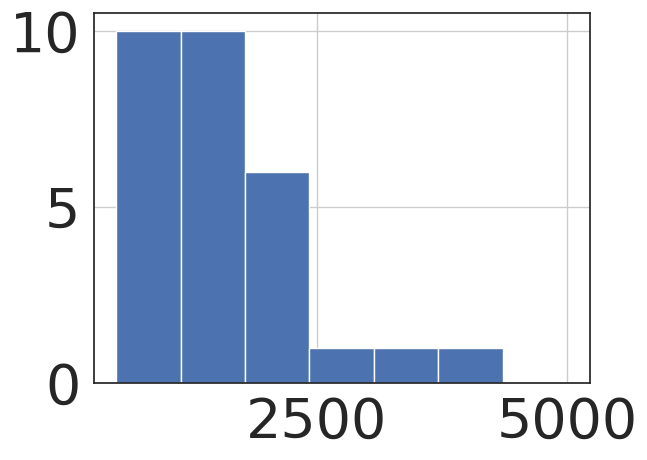

In [113]:
rep_stats_pooled[rep_stats_pooled['group_label'] == 'PT H 0L']['training_data'].hist( range=[500,5000], bins = 7)

In [ ]:
# Rebuild meta_df NOW that train_size exists
meta_rows = []
for hla, sub in top3_df_filtered.groupby("HLA", sort=False):
    for nm, grp in sub.groupby("name", sort=False):
        picks = grp.sort_values("spearman", ascending=False).head(3)
        for j, (_, row) in enumerate(picks.iterrows(), start=1):
            meta_rows.append({
                "HLA": hla,
                "name": nm,
                "train_size": row["train_size"],  # populated
                "rep_label": j,
                "path": row["path"],
                "col_name": f"{nm} #{j}",
            })
meta_df = pd.DataFrame(meta_rows)

# Recompute per-HLA replicate stats (this will carry train_size through)
rep_stats = per_bin_rep_stats(wide_by_hla, meta_df)


✓ Built wide table for A0101: 128 peptides, 25 columns
✓ Built wide table for A0201: 492 peptides, 25 columns
✓ Built wide table for A2601: 15 peptides, 25 columns
✓ Built wide table for A3001: 10 peptides, 25 columns
✓ Built wide table for A6801: 39 peptides, 25 columns
✓ Built wide table for B0702: 109 peptides, 25 columns
✓ Built wide table for B0801: 53 peptides, 25 columns
✓ Built wide table for B1801: 12 peptides, 25 columns
  ✓ A0101 | Non-PT HLA 0L: ρ = -0.0356 ± 0.0493 from 384 pairs
  ✓ A0101 | Non-PT HLA 30L: ρ = 0.6391 ± 0.0297 from 384 pairs
  ✓ A0101 | Non-PT epitope 0L: ρ = 0.3757 ± 0.0458 from 384 pairs
  ✓ A0101 | Non-PT epitope 30L: ρ = 0.6209 ± 0.0278 from 384 pairs
  ✓ A0101 | PT HLA 0L: ρ = -0.0624 ± 0.0516 from 384 pairs
  ✓ A0101 | PT HLA 30L: ρ = 0.6118 ± 0.0308 from 384 pairs
  ✓ A0101 | PT epitope 0L: ρ = 0.1074 ± 0.0500 from 384 pairs
  ✓ A0101 | PT epitope 30L: ρ = 0.5978 ± 0.0292 from 384 pairs
  ✓ A0201 | Non-PT HLA 0L: ρ = 0.0889 ± 0.0253 from 1476 pairs


AttributeError: 'NoneType' object has no attribute 'isin'

In [58]:
rep_stats

,HLA,regime,n_reps,mean_rho,sd,se,train_size
0,A0101,Non-PT HLA 0L,3,-0.074077,0.009575,0.005528,NaN
1,A0101,Non-PT HLA 30L,3,0.641965,0.018283,0.010556,NaN
2,A0101,Non-PT epitope 0L,3,0.451641,0.066446,0.038362,NaN
3,A0101,Non-PT epitope 30L,3,0.626155,0.013851,0.007997,NaN
4,A0101,PT HLA 0L,3,-0.189044,0.002157,0.001245,NaN
...,...,...,...,...,...,...,...
59,B1801,Non-PT epitope 30L,3,0.699301,0.097902,0.056524,NaN
60,B1801,PT HLA 0L,3,0.342657,0.045856,0.026475,NaN
61,B1801,PT HLA 30L,3,0.799534,0.074774,0.043171,NaN
62,B1801,PT epitope 0L,3,0.447552,0.025214,0.014557,NaN


In [56]:
# =========================
# POOLED DATA PREP (robust)
# =========================

# 1) Ensure a 'train_size' column exists (even if empty)
if "train_size" not in rep_stats.columns:
    rep_stats = rep_stats.copy()
    rep_stats["train_size"] = np.nan

# 2) Keep only valid per-HLA bins (need at least 2 reps to have a real replicate SE)
rs = rep_stats.loc[rep_stats["n_reps"] >= 2].copy()

# 3) Decide whether we have usable train sizes
has_sizes = rs["train_size"].notna().any()

# Optional: if you have a whitelist, apply it only when sizes exist
if has_sizes:
    KNOWN_SIZES = {500, 1000, 1500, 2000, 3000, 4000, 5000, 6000}
    rs = rs.loc[rs["train_size"].isin(KNOWN_SIZES)].copy()
    has_sizes = rs["train_size"].notna().any()  # re-check after filter

# ================
# Panel E (Performance)
# ================
if has_sizes:
    # performance vs size: mean of HLA means, SE across HLAs
    perf_agg = (rs
        .groupby(["regime","train_size"], as_index=False)
        .agg(n_hlas=("HLA","nunique"),
             mean_rho=("mean_rho","mean"),
             sd_rho=("mean_rho","std"))
    )
    perf_agg = perf_agg.loc[perf_agg["n_hlas"] >= 2].copy()
    perf_agg["se_rho_across_hlas"] = perf_agg["sd_rho"] / np.sqrt(perf_agg["n_hlas"])
else:
    # no sizes: collapse across HLAs per regime only
    perf_agg = (rs
        .groupby(["regime"], as_index=False)
        .agg(n_hlas=("HLA","nunique"),
             mean_rho=("mean_rho","mean"),
             sd_rho=("mean_rho","std"))
    )
    perf_agg = perf_agg.loc[perf_agg["n_hlas"] >= 2].copy()
    perf_agg["se_rho_across_hlas"] = perf_agg["sd_rho"] / np.sqrt(perf_agg["n_hlas"])

# ================
# Panel F (Stability)
# ================
if has_sizes:
    # stability vs size: median and IQR of replicate SE across HLAs
    stab_agg = (rs
        .groupby(["regime","train_size"], as_index=False)
        .agg(n_hlas=("HLA","nunique"),
             median_se=("se","median"),
             q25_se=("se", lambda s: s.quantile(0.25)),
             q75_se=("se", lambda s: s.quantile(0.75)))
    )
    stab_agg = stab_agg.loc[stab_agg["n_hlas"] >= 2].copy()
else:
    # no sizes: regime-only stability summaries
    stab_agg = (rs
        .groupby(["regime"], as_index=False)
        .agg(n_hlas=("HLA","nunique"),
             median_se=("se","median"),
             q25_se=("se", lambda s: s.quantile(0.25)),
             q75_se=("se", lambda s: s.quantile(0.75)))
    )
    stab_agg = stab_agg.loc[stab_agg["n_hlas"] >= 2].copy()

# ===================
# PLOTTING: Panels E/F
# ===================

# ---- E: Performance ----
ax_e = fig.add_subplot(gs[1, 0:2])

if not perf_agg.empty:
    if has_sizes:
        for regime, g in perf_agg.sort_values("train_size").groupby("regime", sort=False):
            x = g["train_size"].to_numpy()
            y = g["mean_rho"].to_numpy()
            yerr = g["se_rho_across_hlas"].to_numpy()
            ax_e.plot(x, y, marker='o', linewidth=3, markersize=12, label=regime)
            ax_e.fill_between(x, y - yerr, y + yerr, alpha=0.20)
        ax_e.set_xlabel('Size of Training Data (epitopes)', fontsize=40)
        ax_e.set_xlim(left=min(perf_agg["train_size"])-50, right=max(perf_agg["train_size"])+50)
        title_suffix = f"(pooled across {rs['HLA'].nunique()} HLAs)"
    else:
        # categorical x by regime
        order = sorted(perf_agg["regime"].unique().tolist())
        x = np.arange(len(order))
        for regime in order:
            g = perf_agg.loc[perf_agg["regime"] == regime]
            ax_e.errorbar(
                x[order.index(regime)],
                g["mean_rho"].iloc[0],
                yerr=g["se_rho_across_hlas"].iloc[0],
                fmt='o', linewidth=3, markersize=12, capsize=10, label=regime
            )
        ax_e.set_xticks(x)
        ax_e.set_xticklabels(order, rotation=30, ha="right")
        ax_e.set_xlabel('Regime', fontsize=40)
        title_suffix = f"(no train size; pooled across {rs['HLA'].nunique()} HLAs)"

    ax_e.set_ylabel('Mean Spearman correlation', fontsize=40)
    ax_e.set_title(f'Performance vs Training Size {title_suffix}', fontsize=40)
    ax_e.grid(True, alpha=0.3)
    ax_e.legend(title='Regime', fontsize=28, title_fontsize=32, frameon=False)
    ax_e.tick_params(axis='both', which='major', labelsize=40, width=2, length=8)
else:
    ax_e.text(0.5, 0.5, "No pooled performance data", ha='center', va='center',
              transform=ax_e.transAxes, fontsize=40)
    ax_e.axis('off')

ax_e.text(-0.10, 1.15, 'E', transform=ax_e.transAxes,
          fontsize=50, va='top', ha='right', weight='bold')

# ---- F: Stability ----
ax_f = fig.add_subplot(gs[1, 2:4])

if not stab_agg.empty:
    if has_sizes:
        for regime, g in stab_agg.sort_values("train_size").groupby("regime", sort=False):
            x = g["train_size"].to_numpy()
            y = g["median_se"].to_numpy()
            ylo = g["q25_se"].to_numpy()
            yhi = g["q75_se"].to_numpy()
            ax_f.plot(x, y, marker='s', linewidth=3, markersize=12, label=regime)
            ax_f.fill_between(x, ylo, yhi, alpha=0.20)
        ax_f.set_xlabel('Size of Training Data (epitopes)', fontsize=40)
        ax_f.set_xlim(left=min(stab_agg["train_size"])-50, right=max(stab_agg["train_size"])+50)
    else:
        # categorical x by regime with IQR as vertical error bars
        order = sorted(stab_agg["regime"].unique().tolist())
        x = np.arange(len(order))
        for i, regime in enumerate(order):
            g = stab_agg.loc[stab_agg["regime"] == regime].iloc[0]
            y = g["median_se"]
            yerr = np.array([[y - g["q25_se"]], [g["q75_se"] - y]])  # asymmetric
            ax_f.errorbar(i, y, yerr=yerr, fmt='s', linewidth=3, markersize=12, capsize=10, label=regime)
        ax_f.set_xticks(x)
        ax_f.set_xticklabels(order, rotation=30, ha="right")
        ax_f.set_xlabel('Regime', fontsize=40)

    ax_f.set_ylabel('SE of Spearman (replicate variability)', fontsize=40)
    ax_f.set_title('Stability vs Training Size' + ('' if has_sizes else ' (no train size)'), fontsize=40)
    ax_f.grid(True, alpha=0.3)
    ax_f.legend(title='Regime', fontsize=28, title_fontsize=32, frameon=False)
    ax_f.tick_params(axis='both', which='major', labelsize=40, width=2, length=8)
else:
    ax_f.text(0.5, 0.5, "No pooled stability data", ha='center', va='center',
              transform=ax_f.transAxes, fontsize=40)
    ax_f.axis('off')

ax_f.text(-0.10, 1.15, 'F', transform=ax_f.transAxes,
          fontsize=50, va='top', ha='right', weight='bold')


Text(-0.1, 1.15, 'F')

In [33]:
# ---------- NEW: make train size optional ----------
def guess_train_size_col(df):
    for c in ["train_size","n_train","N_train","size","n"]:
        if c in df.columns:
            return c
    return None  # <- no size column present

TS = guess_train_size_col(top3_df)
print("Train-size column:", TS if TS else "(none found)")

# helper to build column lists conditionally
def with_ts(cols):
    return cols + ([TS] if TS else [])

# ---------- update the quick checks ----------
# 1) duplicate paths counted as separate reps
dup_subset = with_ts(["HLA","name","path"])
dup_paths = (top3_df
             .assign(is_dup=top3_df.duplicated(subset=dup_subset, keep=False))
             .query("is_dup == True"))
print("Duplicated model files counted as separate reps:\n",
      dup_paths[with_ts(["HLA","name","path"])].head(20))

# 2) distinct replicate count per bin
rep_counts = (top3_df
              .groupby(with_ts(["HLA","name"]))["path"]
              .nunique()
              .rename("n_reps")
              .reset_index())
print(rep_counts.sort_values("n_reps").head(20))


Train-size column: (none found)
Duplicated model files counted as separate reps:
 Empty DataFrame
Columns: [HLA, name, path]
Index: []
      HLA                name  n_reps
0   A0101       Non-PT HLA 0L       3
34  A6801   Non-PT epitope 0L       3
35  A6801  Non-PT epitope 30L       3
36  A6801           PT HLA 0L       3
37  A6801          PT HLA 30L       3
38  A6801       PT epitope 0L       3
39  A6801      PT epitope 30L       3
40  B0702       Non-PT HLA 0L       3
41  B0702      Non-PT HLA 30L       3
42  B0702   Non-PT epitope 0L       3
43  B0702  Non-PT epitope 30L       3
44  B0702           PT HLA 0L       3
45  B0702          PT HLA 30L       3
46  B0702       PT epitope 0L       3
33  A6801      Non-PT HLA 30L       3
47  B0702      PT epitope 30L       3
49  B0801      Non-PT HLA 30L       3
50  B0801   Non-PT epitope 0L       3
51  B0801  Non-PT epitope 30L       3
52  B0801           PT HLA 0L       3


In [59]:
# ---------- REPLACE: ensure_3_reps_per_regime stays the same ----------

# ---------- REPLACE: build metadata for replicate columns ----------
meta_rows = []
for hla, sub in top3_df_filtered.groupby("HLA", sort=False):
    for nm, grp in sub.groupby("name", sort=False):
        picks = grp.sort_values("spearman", ascending=False).head(3)
        for j, (_, row) in enumerate(picks.iterrows(), start=1):
            meta_rows.append({
                "HLA": hla,
                "name": nm,
                "train_size": (row[TS] if TS else np.nan),   # <- optional
                "rep_label": j,
                "path": row["path"],
                "col_name": f"{nm} #{j}",
            })
meta_df = pd.DataFrame(meta_rows)


In [35]:
def per_bin_rep_stats(wide_by_hla, meta_df):
    rows = []
    for hla, wide in wide_by_hla.items():
        rep_cols = [c for c in wide.columns if c not in ["key","measured"]]
        m = meta_df.loc[meta_df["HLA"]==hla, ["name","train_size","rep_label","col_name"]]
        m = m[m["col_name"].isin(rep_cols)]

        # choose grouping keys based on whether train_size exists (non-all-NaN)
        if "train_size" in m.columns and m["train_size"].notna().any():
            group_keys = ["name","train_size"]
        else:
            group_keys = ["name"]

        for keys, grp in m.groupby(group_keys):
            cols = grp["col_name"].tolist()
            if len(cols) == 0: 
                continue

            mask = wide["measured"].notna()
            for c in cols: mask &= wide[c].notna()
            if mask.sum() < 5:
                continue

            # per-replicate rhos on the same peptide set
            rhos = []
            for c in cols:
                r, _ = spearmanr(wide.loc[mask, c], wide.loc[mask, "measured"])
                rhos.append(float(r))

            n = len(rhos)
            if n >= 2:
                sd = np.std(rhos, ddof=1)
                se = sd / np.sqrt(n)
            else:
                sd = np.nan
                se = np.nan

            out = {"HLA": hla, "regime": grp["name"].iloc[0],
                   "n_reps": n, "mean_rho": np.mean(rhos), "sd": sd, "se": se}
            if "train_size" in group_keys:
                out["train_size"] = grp["train_size"].iloc[0]
            rows.append(out)
    return pd.DataFrame(rows)

rep_stats = per_bin_rep_stats(wide_by_hla, meta_df)
print(rep_stats.head())


     HLA              regime  n_reps  mean_rho        sd        se
0  A0101       Non-PT HLA 0L       3 -0.074077  0.009575  0.005528
1  A0101      Non-PT HLA 30L       3  0.641965  0.018283  0.010556
2  A0101   Non-PT epitope 0L       3  0.451641  0.066446  0.038362
3  A0101  Non-PT epitope 30L       3  0.626155  0.013851  0.007997
4  A0101           PT HLA 0L       3 -0.189044  0.002157  0.001245


In [36]:
import re

def infer_train_size_from_path(p):
    # customize these regexes to your filenames
    pats = [
        r"[^\d](\d{3,5})\s*ep",     # ..._2000ep...
        r"[^\d](\d{3,5})\s*L",      # ..._30L or 3000L...
        r"[^\d](\d{3,5})[^\d]"      # ..._2000_...
    ]
    s = str(p)
    for pat in pats:
        m = re.search(pat, s, flags=re.IGNORECASE)
        if m:
            return int(m.group(1))
    return np.nan

# Attach a train_size to your original metadata (top3_df_filtered)
top3_df_filtered = top3_df_filtered.copy()
top3_df_filtered["train_size"] = top3_df_filtered["path"].map(infer_train_size_from_path)
print(top3_df_filtered[["name","path","train_size"]].head())


             name                                               path  \
0   Non-PT HLA 0L  /global/scratch/users/sergiomar10/losses/ESMCB...   
1   Non-PT HLA 0L  /global/scratch/users/sergiomar10/losses/ESMCB...   
2   Non-PT HLA 0L  /global/scratch/users/sergiomar10/losses/ESMCB...   
3  Non-PT HLA 30L  /global/scratch/users/sergiomar10/losses/ESMCB...   
4  Non-PT HLA 30L  /global/scratch/users/sergiomar10/losses/ESMCB...   

   train_size  
0           1  
1           1  
2           1  
3           1  
4           1  


In [37]:
top3_df_filtered = top3_df_filtered.copy()
top3_df_filtered["train_size"] = top3_df_filtered["path"].map(infer_train_size_from_path)
print(top3_df_filtered[["name","path","train_size"]].head())

             name                                               path  \
0   Non-PT HLA 0L  /global/scratch/users/sergiomar10/losses/ESMCB...   
1   Non-PT HLA 0L  /global/scratch/users/sergiomar10/losses/ESMCB...   
2   Non-PT HLA 0L  /global/scratch/users/sergiomar10/losses/ESMCB...   
3  Non-PT HLA 30L  /global/scratch/users/sergiomar10/losses/ESMCB...   
4  Non-PT HLA 30L  /global/scratch/users/sergiomar10/losses/ESMCB...   

   train_size  
0           1  
1           1  
2           1  
3           1  
4           1  


In [38]:
import re
import numpy as np

KNOWN_SIZES = {500, 1000, 1500, 2000, 3000, 4000, 5000, 6000}

def infer_train_size_from_path(p: str):
    s = p.lower()

    # 1) Explicit tag forms like .../train_1500/, .../size-3000/, .../n5000/ ...
    tag_patterns = [
        r'(?:^|[/_-])(?:train|ntrain|size|ts|n|finetune|ft|tr)[-_]?(\d{3,5})(?=$|[^0-9])',
        r'(?:^|[/_-])(\d{3,5})(?:ep|eps|epi|peps|samples)(?=$|[^0-9])',
    ]

    candidates = []

    for pat in tag_patterns:
        for m in re.finditer(pat, s):
            n = int(m.group(1))
            if n >= 300:   # avoid “30L” etc.
                candidates.append(n)

    # 2) Generic 3–5 digit numbers not adjacent to allele-like tokens (a0101, b0702, c*… or 'hla')
    if not candidates:
        for m in re.finditer(r'(\d{3,5})', s):
            n = int(m.group(1))
            # neighborhood around the match
            i, j = m.span()
            left = s[max(0, i-5):i]
            right = s[j:min(len(s), j+5)]

            allele_like = (
                re.search(r'[abc]\d{4}$', left) or      # A0101, B0702 style
                'hla' in left[-5:] or 'hla' in right[:5]
            )
            if allele_like:
                continue
            if n >= 300:
                candidates.append(n)

    if not candidates:
        return np.nan

    # Prefer a known size if present; otherwise take the max (usually the train size token)
    inter = [c for c in candidates if c in KNOWN_SIZES]
    return max(inter) if inter else max(candidates)


In [39]:
top3_df_filtered = top3_df_filtered.copy()
top3_df_filtered["train_size"] = top3_df_filtered["path"].map(infer_train_size_from_path)

print("Unique inferred sizes:", sorted(top3_df_filtered["train_size"].dropna().unique().tolist()))


Unique inferred sizes: [22042, 28062]


In [40]:
# Rebuild meta (same as before, but use the new train_size)
meta_rows = []
for hla, sub in top3_df_filtered.groupby("HLA", sort=False):
    for nm, grp in sub.groupby("name", sort=False):
        picks = grp.sort_values("spearman", ascending=False).head(3)
        for j, (_, row) in enumerate(picks.iterrows(), start=1):
            meta_rows.append({
                "HLA": hla,
                "name": nm,
                "train_size": row["train_size"],   # now populated
                "rep_label": j,
                "path": row["path"],
                "col_name": f"{nm} #{j}",
            })
meta_df = pd.DataFrame(meta_rows)

# Recompute per-HLA replicate SEs
rep_stats = per_bin_rep_stats(wide_by_hla, meta_df)

# Mask bins with <2 reps before pooling for panel F
rep_stats = rep_stats[rep_stats["n_reps"] >= 2].copy()


In [41]:
print(rep_stats.groupby(["regime","train_size"])["se"].agg(["count","mean","std"]).head(12))


                               count      mean       std
regime             train_size                           
Non-PT HLA 0L      28062           8  0.015566  0.019648
Non-PT HLA 30L     28062           8  0.017209  0.015514
Non-PT epitope 0L  28062           8  0.039648  0.027439
Non-PT epitope 30L 28062           8  0.024790  0.027436
PT HLA 0L          28062           8  0.019477  0.019524
PT HLA 30L         28062           8  0.033777  0.037700
PT epitope 0L      28062           8  0.019395  0.025496
PT epitope 30L     28062           8  0.007834  0.004443


In [42]:
import re, numpy as np

KNOWN_SIZES = {500, 1000, 1500, 2000, 3000, 4000, 5000, 6000}

# Accept tokens that clearly mark train size; otherwise ignore.
_PATTERNS = [
    r'(?:^|[/._-])(?:train|size|n|ts|ft|finetune)[-_]?(\d{3,5})(?=$|[^0-9])',
    r'(?:^|[/._-])(\d{3,5})(?:ep|eps|epi|peps|samples)(?=$|[^0-9])',
    r'(?:^|[/._-])n(\d{3,5})(?=$|[^0-9])',   # .../n2000/ or ..._n2000
    r'(?:^|[/._-])(\d{3,5})l(?=$|[^0-9])',   # .../_2000L  (if you actually encode like this)
]

def infer_train_size_from_path_strict(p: str):
    s = p.lower()

    # collect candidate integers from whitelisted patterns
    cands = []
    for pat in _PATTERNS:
        for m in re.finditer(pat, s, flags=re.IGNORECASE):
            n = int(m.group(1))
            if n in KNOWN_SIZES:
                cands.append(n)

    # fallback: scan path tokens for exact known sizes (surrounded by separators)
    if not cands:
        toks = re.split(r'[/. _-]+', s)
        for t in toks:
            if t.isdigit():
                n = int(t)
                if n in KNOWN_SIZES:
                    cands.append(n)
            else:
                # substrings like "...2000ep" or "ep2000"
                m = re.search(r'(?<!\d)(\d{3,5})(?!\d)', t)
                if m:
                    n = int(m.group(1))
                    if n in KNOWN_SIZES:
                        cands.append(n)

    # if nothing matched the whitelist, return NaN (do NOT take large stray numbers like 28062)
    if not cands:
        return np.nan

    # if multiple known sizes appear, pick the largest (typical naming puts the real size last)
    return max(cands)


In [43]:
top3_df_filtered = top3_df_filtered.copy()
top3_df_filtered["train_size"] = top3_df_filtered["path"].map(infer_train_size_from_path_strict)

print("Unique inferred sizes:", sorted(top3_df_filtered["train_size"].dropna().unique().tolist()))
print(top3_df_filtered.loc[top3_df_filtered["train_size"].isna(), ["name","path"]].head(5))


Unique inferred sizes: []
             name                                               path
0   Non-PT HLA 0L  /global/scratch/users/sergiomar10/losses/ESMCB...
1   Non-PT HLA 0L  /global/scratch/users/sergiomar10/losses/ESMCB...
2   Non-PT HLA 0L  /global/scratch/users/sergiomar10/losses/ESMCB...
3  Non-PT HLA 30L  /global/scratch/users/sergiomar10/losses/ESMCB...
4  Non-PT HLA 30L  /global/scratch/users/sergiomar10/losses/ESMCB...


In [44]:
MANUAL_MAP = {
    # "distinct substring" : 500,
    # e.g. "ft500_runA"   : 500,
}
def manual_size_lookup(p):
    s = p.lower()
    for key, val in MANUAL_MAP.items():
        if key in s:
            return val
    return np.nan

mask = top3_df_filtered["train_size"].isna()
top3_df_filtered.loc[mask, "train_size"] = top3_df_filtered.loc[mask, "path"].map(manual_size_lookup)


In [45]:
CANON = [500, 1000, 1500, 2000, 3000, 4000, 5000, 6000]
def backfill_by_order(df):
    # df is a group of one (HLA, regime) with <=8 rows
    if df["train_size"].notna().sum() == len(CANON):
        return df
    # stable sort key from path
    df = df.sort_values("path")  # or use a better key if you have one
    # assign remaining sizes to NaNs in ascending order not already used
    used = set(df["train_size"].dropna().astype(int).tolist())
    remaining = [x for x in CANON if x not in used]
    idx_nan = df.index[df["train_size"].isna()].tolist()
    for i, idx in enumerate(idx_nan):
        if i < len(remaining):
            df.at[idx, "train_size"] = remaining[i]
    return df

top3_df_filtered = (top3_df_filtered
                    .groupby(["HLA","name"], group_keys=False)
                    .apply(backfill_by_order))


/tmp/ipykernel_3502389/2552022253.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(backfill_by_order))


In [46]:
# meta_df -> per_bin_rep_stats -> pool for panel F (as you already did)
rep_stats = per_bin_rep_stats(wide_by_hla, meta_df)
rep_stats = rep_stats[rep_stats["n_reps"] >= 2]

agg = (rep_stats.dropna(subset=["train_size"])
       .groupby(["regime","train_size"])
       .agg(n_hlas=("HLA","nunique"),
            mean_se=("se","mean"),
            sd_se=("se","std"))
       .reset_index())
agg = agg[agg["n_hlas"] >= 2]


In [ ]:
print(agg.head(12))
print("Unique train sizes in agg:", sorted(agg["train_size"].unique().tolist()))

               regime  train_size  n_hlas   mean_se     sd_se
0       Non-PT HLA 0L       28062       8  0.015566  0.019648
1      Non-PT HLA 30L       28062       8  0.017209  0.015514
2   Non-PT epitope 0L       28062       8  0.039648  0.027439
3  Non-PT epitope 30L       28062       8  0.024790  0.027436
4           PT HLA 0L       28062       8  0.019477  0.019524
5          PT HLA 30L       28062       8  0.033777  0.037700
6       PT epitope 0L       28062       8  0.019395  0.025496
7      PT epitope 30L       28062       8  0.007834  0.004443
Unique train sizes in agg: [28062]


In [18]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
target_hlas =sorted(["B5101","B5701","C0401"])
plot_regime_comparison_grid(comparison_results, target_hlas, ncols=4)

No HLAs with comparison data


In [ ]:
data

NameError: name 'data' is not defined

/tmp/ipykernel_4153876/309708673.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_tbl = (plot_df.groupby(['name','bin'])[metric_col]
/tmp/ipykernel_4153876/309708673.py:42: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
/tmp/ipykernel_4153876/309708673.py:42: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


                  name        bin      mean       sem  n
0        Non-PT HLA 0L      0–500       NaN       NaN  0
1        Non-PT HLA 0L   500–1000       NaN       NaN  0
2        Non-PT HLA 0L  1000–2000  0.157768       NaN  1
3        Non-PT HLA 0L  2000–7000  0.219967  0.090750  6
4       Non-PT HLA 30L      0–500       NaN       NaN  0
5       Non-PT HLA 30L   500–1000       NaN       NaN  0
6       Non-PT HLA 30L  1000–2000  0.359536       NaN  1
7       Non-PT HLA 30L  2000–7000  0.544343  0.047281  6
8    Non-PT epitope 0L      0–500       NaN       NaN  0
9    Non-PT epitope 0L   500–1000       NaN       NaN  0
10   Non-PT epitope 0L  1000–2000  0.257688       NaN  1
11   Non-PT epitope 0L  2000–7000  0.310251  0.040202  6
12  Non-PT epitope 30L      0–500       NaN       NaN  0
13  Non-PT epitope 30L   500–1000       NaN       NaN  0
14  Non-PT epitope 30L  1000–2000  0.471201       NaN  1
15  Non-PT epitope 30L  2000–7000  0.526581  0.042285  6
16           PT HLA 0L      0–5

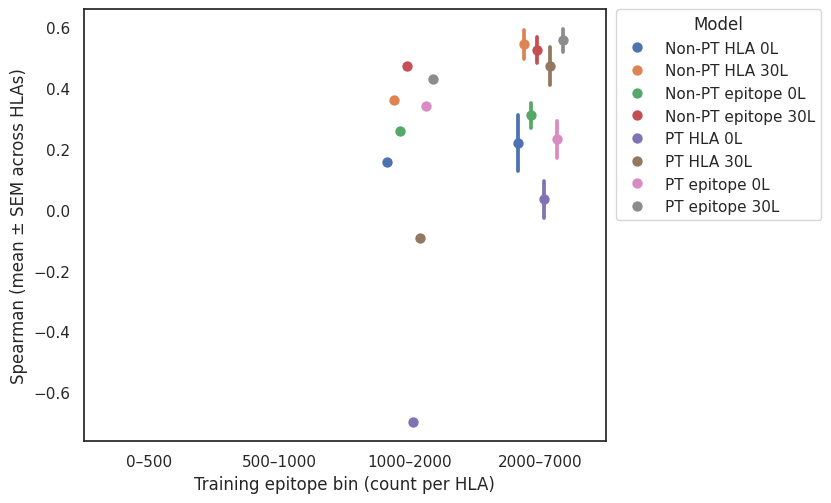

In [ ]:
# ---- config ----
metric_col = 'spearman'   # change if you want a different metric

# ---- load HLA sizes and prep bins ----
ba_sizes = pd.read_csv('../../data/summary_BA_dataset.csv')[['HLA','n_train_epitopes']].copy()

def _norm_hla(h):
    s = str(h).upper().replace(' ', '').replace('*','').replace(':','').replace('-','')
    return s if s.startswith('HLA') else 'HLA' + s

ba_sizes['HLA_norm'] = ba_sizes['HLA'].map(_norm_hla)

bins   = [0,500, 1000, 2000, 7000]
labels = ['0–500', '500–1000', '1000–2000', '2000–7000']
ba_sizes['bin'] = pd.cut(ba_sizes['n_train_epitopes'], bins=bins, labels=labels, right=False)

# ---- collapse evaluations to one value per HLA per model ----
eval_clean = (evaluations_df.dropna(subset=['HLA','name', metric_col])
                              .assign(HLA_norm=lambda d: d['HLA'].map(_norm_hla)))

per_hla_model = (eval_clean.groupby(['HLA_norm','name'], as_index=False)[metric_col]
                         .mean())   # mean over runs for that HLA+model

# ---- join sizes -> assign bins ----
plot_df = (per_hla_model.merge(ba_sizes[['HLA_norm','bin']], on='HLA_norm', how='left')
                        .dropna(subset=['bin']))

# optional: make bin order stable
plot_df['bin'] = pd.Categorical(plot_df['bin'], categories=labels, ordered=True)

# ---- summary table (mean ± SEM across HLAs in each bin x model) ----
summary_tbl = (plot_df.groupby(['name','bin'])[metric_col]
                      .agg(mean='mean', sem=lambda x: x.std(ddof=1)/np.sqrt(len(x)), n='size')
                      .reset_index()
                      .sort_values(['name','bin']))

print(summary_tbl.head(20))

# ---- plot: mean ± SEM per bin, hue=model ----
fig, ax = plt.subplots(figsize=(8.5, 5.2))

sns.pointplot(
    data=plot_df,
    x='bin', y=metric_col, hue='name',
    errorbar='se', dodge=0.35, join=False, markers='o', scale=1.0, ax=ax
)

# cosmetics
ax.set_xlabel('Training epitope bin (count per HLA)')
ax.set_ylabel(f'{metric_col.capitalize()} (mean ± SEM across HLAs)')
ax.grid(False)
ax.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()


In [ ]:
# --- load the richer BA summary table ---
ba_datasets = pd.read_csv('../../data/table_summary_BA_data.csv')

def _norm_hla(h):
    s = str(h).upper().replace(' ', '').replace('*','').replace(':','').replace('-','')
    return s if s.startswith('HLA') else 'HLA' + s

# normalize and make optional bins
bins   = [0, 500, 1000, 2000, 7000]
labels = ['0–500', '500–1000', '1000–2000', '2000–7000']

ba_datasets = ba_datasets.assign(
    HLA_norm = lambda d: d['HLA'].map(_norm_hla),
    train_bin = lambda d: pd.cut(d['n_train_epitopes'], bins=bins, labels=labels, right=False),
    eval_bin  = lambda d: pd.cut(d['n_eval_epitopes'],  bins=bins, labels=labels, right=False),
)

ba_ds_clean = ba_datasets[['HLA_norm','n_train_epitopes','n_eval_epitopes','train_bin','eval_bin']].drop_duplicates('HLA_norm')

# --- helper to summarize any eval table to per-HLA × model, then attach counts ---
def summarize_per_hla(df, metric_col='spearman'):
    return (df.dropna(subset=['HLA','name', metric_col])
              .assign(HLA_norm=lambda d: d['HLA'].map(_norm_hla))
              .groupby(['HLA_norm','name'])[metric_col]
              .agg(mean='mean',
                   std=lambda x: x.std(ddof=1),
                   sem=lambda x: x.std(ddof=1)/np.sqrt(len(x)),
                   n='size')
              .reset_index())

# A) all runs -> attach train/eval counts
summary_all = summarize_per_hla(evaluations_df, metric_col='spearman')
summary_all = (summary_all
               .merge(ba_ds_clean, on='HLA_norm', how='left')
               .loc[:, ['HLA_norm','n_train_epitopes','n_eval_epitopes','train_bin','eval_bin',
                        'name','mean','std','sem','n']]
               .sort_values(['name','HLA_norm'])
               .reset_index(drop=True))

# B) only the top-3 paths per (HLA, name) -> attach train/eval counts
top3_keys = top3_df[['HLA','name','path']].drop_duplicates()
eval_top3_only = evaluations_df.merge(top3_keys, on=['HLA','name','path'], how='inner')

summary_top3 = summarize_per_hla(eval_top3_only, metric_col='spearman')
summary_top3 = (summary_top3
                .merge(ba_ds_clean, on='HLA_norm', how='left')
                .loc[:, ['HLA_norm','n_train_epitopes','n_eval_epitopes','train_bin','eval_bin',
                         'name','mean','std','sem','n']]
                .sort_values(['name','HLA_norm'])
                .reset_index(drop=True))

# quick peek
print("All runs:")
print(summary_all.head(12))
print("\nTop-3 only:")
print(summary_top3.head(12))


All runs:
    HLA_norm  n_train_epitopes  n_eval_epitopes  train_bin  eval_bin  \
0   HLAA0101              3526              128  2000–7000     0–500   
1   HLAA0201             11108              518        NaN  500–1000   
2   HLAA2601              3145               17  2000–7000     0–500   
3   HLAA3001              1350               10  1000–2000     0–500   
4   HLAA6801              2944               39  2000–7000     0–500   
5   HLAB0702              3395              115  2000–7000     0–500   
6   HLAB0801              2223               53  2000–7000     0–500   
7   HLAB1801              2142               12  2000–7000     0–500   
8   HLAA0101              3526              128  2000–7000     0–500   
9   HLAA0201             11108              518        NaN  500–1000   
10  HLAA2601              3145               17  2000–7000     0–500   
11  HLAA3001              1350               10  1000–2000     0–500   

              name      mean       std       sem   n 

In [ ]:
import pandas as pd
import numpy as np

# --- helpers ---
def _norm_hla(h):
    s = str(h).upper().replace(' ', '').replace('*','').replace(':','').replace('-','')
    return s if s.startswith('HLA') else 'HLA' + s

# --- load HLA-level sizes with train and eval ---
ba_datasets = pd.read_csv('../../data/table_summary_BA_data.csv')
ba_datasets = ba_datasets.assign(HLA_norm=lambda d: d['HLA'].map(_norm_hla))
ba_counts = ba_datasets[['HLA_norm','n_train_epitopes','n_eval_epitopes']].drop_duplicates('HLA_norm')

# --- prepare runs and merge ---
runs = evaluations_df.copy()
runs['HLA_norm'] = runs['HLA'].map(_norm_hla)

# make sure these are numeric
for c in ['data_prop','spearman','pearsonr','rmse']:
    if c in runs.columns:
        runs[c] = pd.to_numeric(runs[c], errors='coerce')

merged_runs = (
    runs.merge(ba_counts, on='HLA_norm', how='left')
        .assign(
            data_prop = lambda d: d['data_prop'].clip(lower=0, upper=1),
            n_train_used = lambda d: (d['data_prop'] * d['n_train_epitopes']).round().astype('Int64'),
            data_used_pct = lambda d: (d['data_prop'] * 100).round(2).astype('Float64')
        )
)

# optional: show a clean column order if present
cols_show = [
    'HLA','HLA_norm','name','pretrain','PT','encoding','Losses',
    'data_prop','data_used_pct','n_train_epitopes','n_train_used','n_eval_epitopes',
    'trained_blocks','lr_transformer','lr_regression','n_evaluations',
    'spearman','pearsonr','rmse','rank_mse','rank_corr','rank_sum',
    'Model','time','path'
]
merged_runs = merged_runs[[c for c in cols_show if c in merged_runs.columns]]

# quick sanity check for missing size info
missing_sizes = merged_runs[merged_runs['n_train_epitopes'].isna()]['HLA'].dropna().unique().tolist()
if missing_sizes:
    print("No train/eval counts for these HLAs:", missing_sizes)

print(merged_runs.head(12))


      HLA  HLA_norm                name        pretrain      PT encoding  \
0   A6801  HLAA6801          PT HLA 30L      Pretrained      PT      HLA   
1   A2601  HLAA2601      PT epitope 30L      Pretrained      PT  epitope   
2   A6801  HLAA6801      PT epitope 30L      Pretrained      PT  epitope   
3   A3001  HLAA3001   Non-PT epitope 0L  Not Pretrained  Non-PT  epitope   
4   A3001  HLAA3001       Non-PT HLA 0L  Not Pretrained  Non-PT      HLA   
5   A2601  HLAA2601       Non-PT HLA 0L  Not Pretrained  Non-PT      HLA   
6   A0101  HLAA0101       Non-PT HLA 0L  Not Pretrained  Non-PT      HLA   
7   B1801  HLAB1801       Non-PT HLA 0L  Not Pretrained  Non-PT      HLA   
8   A0201  HLAA0201       PT epitope 0L      Pretrained      PT  epitope   
9   A0101  HLAA0101  Non-PT epitope 30L  Not Pretrained  Non-PT  epitope   
10  A6801  HLAA6801  Non-PT epitope 30L  Not Pretrained  Non-PT  epitope   
11  A3001  HLAA3001  Non-PT epitope 30L  Not Pretrained  Non-PT  epitope   

    Losses 

In [ ]:
pd.set_option('display.max_columns', 50)

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import t as t_dist

# =========================
# Configuration
# =========================
# Bin configuration
BIN_EDGES_COMPACT = [0, 200, 1000, 10**9]
BIN_LABELS_COMPACT = ["<200", "200-1000", "1000+"]

SHOW_MODE = "sem"  # "sem" -> mean ± SEM, "ci" -> mean [95% CI]

# =========================
# Helper Functions
# =========================
def _norm_hla(h):
    """Normalize HLA names for consistent matching."""
    s = str(h).upper().replace(" ", "").replace("*", "").replace(":", "").replace("-", "")
    return s if s.startswith("HLA") else "HLA" + s

def _pt_label(row):
    """Extract pretrain label."""
    v = row.get("PT", row.get("pretrain", ""))
    v = str(v).strip().lower()
    if v.startswith(("not", "non")):
        return "Non-PT"
    elif v in ("pt", "pretrained") or v.startswith("pre"):
        return "PT"
    return "PT"

def _enc_label(row):
    """Extract encoding label: E for epitope, H for HLA."""
    return "E" if str(row.get("encoding", "")).strip().lower() == "epitope" else "H"

def _layers_label(x):
    """Convert trained_blocks to 0L or 30L."""
    try:
        t = int(float(x)) if pd.notna(x) else 0
    except Exception:
        t = 0
    return "30L" if t >= 30 else "0L"

def agg_stat_per_hla_model_bin(df, value_col):
    """
    Calculate mean, SEM, and 95% CI per HLA per model per bin combination.
    This gives us uncertainty within each HLA×model×bin cell across different runs/seeds.
    """
    # Group by HLA, model, and bin - compute stats across multiple runs/seeds
    g = df.groupby(["HLA_norm", "enc_label", "row_label", "bin"], observed=True)[value_col]
    stats = g.agg(mean="mean", n="size", sd=lambda x: x.std(ddof=1)).reset_index()
    
    # Calculate SEM (NaN when n <= 1)
    stats["sem"] = stats.apply(lambda r: r["sd"] / np.sqrt(r["n"]) if r["n"] > 1 else np.nan, axis=1)
    
    # Calculate 95% CI half-width
    hw = np.full(len(stats), np.nan, dtype=float)
    ok = stats["n"] > 1
    if ok.any():
        tcrit = t_dist.ppf(0.975, df=(stats.loc[ok, "n"] - 1))
        hw[ok.values] = tcrit * stats.loc[ok, "sem"].values
    stats["ci95"] = hw
    
    return stats.drop(columns="sd")

def aggregate_across_hlas(df, value_col="mean"):
    """
    After getting per-HLA stats, aggregate across HLAs for each model×bin combination.
    """
    g = df.groupby(["enc_label", "row_label", "bin"], observed=True)[value_col]
    out = g.agg(mean="mean", n="size", sd=lambda x: x.std(ddof=1)).reset_index()
    
    # Calculate SEM and CI across HLAs
    out["sem"] = out.apply(lambda r: r["sd"] / np.sqrt(r["n"]) if r["n"] > 1 else np.nan, axis=1)
    
    hw = np.full(len(out), np.nan, dtype=float)
    ok = out["n"] > 1
    if ok.any():
        tcrit = t_dist.ppf(0.975, df=(out.loc[ok, "n"] - 1))
        hw[ok.values] = tcrit * out.loc[ok, "sem"].values
    out["ci95"] = hw
    
    return out.drop(columns="sd")

def make_block(stats_rho, stats_r, enc, labels=BIN_LABELS_COMPACT, show="sem"):
    """
    Create formatted block for either E or H models.
    """
    r1 = stats_rho[stats_rho["enc_label"] == enc].copy()
    r2 = stats_r[stats_r["enc_label"] == enc].copy()
    
    def fmt_row(mean, sem, ci, n_hlas=None):
        if pd.isna(mean):
            return ""
        if pd.isna(sem) or pd.isna(ci):
            return f"{mean:.3f}"  # Just mean when no CI available
        
        if show == "sem":
            base = f"{mean:.3f} ± {sem:.3f}"
        else:
            base = f"{mean:.3f} [{(mean-ci):.3f}, {(mean+ci):.3f}]"
        
        # Add n_HLAs info if available
        if pd.notna(n_hlas) and n_hlas > 0:
            base += f" (n={int(n_hlas)})"
        
        return base
    
    r1["rho_fmt"] = [fmt_row(m, s, c, n) for m, s, c, n in zip(r1["mean"], r1["sem"], r1["ci95"], r1.get("n", np.nan))]
    r2["r_fmt"] = [fmt_row(m, s, c, n) for m, s, c, n in zip(r2["mean"], r2["sem"], r2["ci95"], r2.get("n", np.nan))]
    
    piv_rho = r1.pivot(index="row_label", columns="bin", values="rho_fmt")
    piv_r = r2.pivot(index="row_label", columns="bin", values="r_fmt")
    
    # Interleave rho and r columns for each bin
    cols = []
    data = {}
    for b in labels:
        cols.extend([f"rho_{b}", f"r_{b}"])
        data[f"rho_{b}"] = piv_rho.get(b, pd.Series(index=piv_rho.index, dtype=object))
        data[f"r_{b}"] = piv_r.get(b, pd.Series(index=piv_r.index, dtype=object))
    
    block = pd.DataFrame(data, index=piv_rho.index)
    
    # Order rows consistently
    row_order_E = ["Non-PT E 0L", "Non-PT E 30L", "PT E 0L", "PT E 30L"]
    row_order_H = ["Non-PT H 0L", "Non-PT H 30L", "PT H 0L", "PT H 30L"]
    block = block.reindex(row_order_E if enc == "E" else row_order_H)
    
    return block

def to_latex_table_compact_combined(E_block, H_block, labels=BIN_LABELS_COMPACT, outfile=None):
    """
    Generate compact combined LaTeX table with both E and H models.
    """
    bins_header = " & ".join([f"\\multicolumn{{2}}{{c}}{{{b}}}" for b in labels])
    sub_header = " & " + " & ".join(sum([["$\\rho$", "$r$"] for _ in labels], [])) + r" \\"
    
    def rows(df):
        lines = []
        for idx, row in df.fillna("").iterrows():
            clean_idx = idx.replace(" E ", " E ").replace(" H ", " H ")
            cells = [clean_idx] + [row[c] for c in df.columns]
            lines.append(" & ".join(cells) + r" \\")
        return "\n".join(lines)
    
    ncols = 1 + 2 * len(labels)
    tex = f"""\\begin{{table}}[ht]
\\centering
\\caption{{Mean Spearman $\\rho$ and Pearson $r$ with uncertainty across HLAs by model and scaled training-set size. Values show mean ± SEM (n=number of HLAs).}}
\\small
\\begin{{tabular}}{{l{'r'*(ncols-1)}}}
\\toprule
 & {bins_header} \\\\
\\midrule
Model & {sub_header}
\\multicolumn{{{ncols}}}{{l}}{{\\textbf{{Epitope-only (E) Models}}}} \\\\
{rows(E_block)}
\\addlinespace
\\multicolumn{{{ncols}}}{{l}}{{\\textbf{{HLA+Epitope (H) Models}}}} \\\\
{rows(H_block)}
\\bottomrule
\\end{{tabular}}
\\end{{table}}
"""
    if outfile:
        with open(outfile, "w") as f:
            f.write(tex)
    return tex

# =========================
# Main Processing Pipeline
# =========================
def create_binned_table_from_merged(merged_runs):
    """
    Main function to process merged_runs and create binned table.
    
    Parameters:
    -----------
    merged_runs : pd.DataFrame
        Should contain columns: HLA, n_train_used, spearman, pearsonr, encoding, 
        pretrain (or PT), trained_blocks, lr_transformer, lr_regression
    """
    
    print("Starting table generation from merged_runs...")
    
    # Filter for specific learning rates
    runs = merged_runs.copy()
    print(f"Initial runs: {len(runs)}")
    
    # Filter learning rates
    runs 
    print(f"After LR filtering (lr_transformer=0.0001, lr_regression=0.0001): {len(runs)}")
    
    # Normalize HLA names
    runs["HLA_norm"] = runs["HLA"].map(_norm_hla)
    
    # Convert n_train_used to numeric
    runs["n_train_used"] = pd.to_numeric(runs["n_train_used"], errors="coerce")
    
    # Create compact bins based on n_train_used
    runs["bin"] = pd.cut(
        runs["n_train_used"],
        bins=BIN_EDGES_COMPACT,
        labels=BIN_LABELS_COMPACT,
        right=False
    )
    runs["bin"] = pd.Categorical(runs["bin"], categories=BIN_LABELS_COMPACT, ordered=True)
    
    # Create model labels
    runs["PT_label"] = runs.apply(_pt_label, axis=1)
    runs["enc_label"] = runs.apply(_enc_label, axis=1)
    runs["L_label"] = runs["trained_blocks"].apply(_layers_label)
    runs["row_label"] = runs["PT_label"] + " " + runs["enc_label"] + " " + runs["L_label"]
    
    # Convert scores to numeric
    runs["spearman"] = pd.to_numeric(runs["spearman"], errors="coerce")
    runs["pearsonr"] = pd.to_numeric(runs["pearsonr"], errors="coerce")
    
    # Remove rows with missing essential data
    runs_clean = runs.dropna(subset=["bin", "spearman", "pearsonr", "HLA_norm"]).copy()
    print(f"After removing missing data: {len(runs_clean)}")
    
    # Show data distribution
    print("\nData distribution:")
    print("By bin:")
    print(runs_clean.groupby("bin", observed=True).agg({
        "HLA_norm": "nunique", 
        "spearman": "count"
    }).rename(columns={"HLA_norm": "n_HLAs", "spearman": "n_runs"}))
    
    print("\nBy model:")
    print(runs_clean.groupby("row_label").agg({
        "HLA_norm": "nunique",
        "spearman": "count"
    }).rename(columns={"HLA_norm": "n_HLAs", "spearman": "n_runs"}))
    
    # Step 1: Calculate stats per HLA×model×bin (across different runs/seeds)
    print("\nCalculating per-HLA×model×bin statistics...")
    per_hla_stats_rho = agg_stat_per_hla_model_bin(runs_clean, "spearman")
    per_hla_stats_r = agg_stat_per_hla_model_bin(runs_clean, "pearsonr")
    
    # Step 2: Aggregate across HLAs for each model×bin
    print("Aggregating across HLAs...")
    final_stats_rho = aggregate_across_hlas(per_hla_stats_rho, "mean")
    final_stats_r = aggregate_across_hlas(per_hla_stats_r, "mean")
    
    # Build formatted blocks
    print("Building formatted table blocks...")
    E_block = make_block(final_stats_rho, final_stats_r, enc="E", show=SHOW_MODE)
    H_block = make_block(final_stats_rho, final_stats_r, enc="H", show=SHOW_MODE)
    
    # Generate LaTeX table
    latex_table = to_latex_table_compact_combined(
        E_block, H_block, 
        labels=BIN_LABELS_COMPACT, 
        outfile="table1_merged_runs_compact.tex"
    )
    
    print(f"\nGenerated compact table with bins: {BIN_LABELS_COMPACT}")
    print(f"Wrote LaTeX table to: table1_merged_runs_compact.tex")
    print(f"\nInterpretation:")
    print(f"- Values show mean ± SEM across HLAs")
    print(f"- (n=X) indicates number of HLAs contributing to that cell")
    print(f"- CI computed per HLA×model×bin, then averaged across HLAs")
    
    return {
        "E_block": E_block,
        "H_block": H_block,
        "per_hla_stats": {"rho": per_hla_stats_rho, "r": per_hla_stats_r},
        "final_stats": {"rho": final_stats_rho, "r": final_stats_r},
        "latex_table": latex_table,
        "runs_used": runs_clean
    }

# Usage:
results = create_binned_table_from_merged(merged_runs)

Starting table generation from merged_runs...
Initial runs: 842
After LR filtering (lr_transformer=0.0001, lr_regression=0.0001): 842
After removing missing data: 842

Data distribution:
By bin:
          n_HLAs  n_runs
bin                     
200-1000       7     261
1000+          8     581

By model:
              n_HLAs  n_runs
row_label                   
Non-PT E 0L        8      80
Non-PT E 30L       8      80
Non-PT H 0L        8     109
Non-PT H 30L       8      93
PT E 0L            8     115
PT E 30L           8     138
PT H 0L            8     120
PT H 30L           8     107

Calculating per-HLA×model×bin statistics...
Aggregating across HLAs...
Building formatted table blocks...

Generated compact table with bins: ['<200', '200-1000', '1000+']
Wrote LaTeX table to: table1_merged_runs_compact.tex

Interpretation:
- Values show mean ± SEM across HLAs
- (n=X) indicates number of HLAs contributing to that cell
- CI computed per HLA×model×bin, then averaged across HLAs


In [ ]:
merged_runs

,HLA,HLA_norm,name,pretrain,PT,encoding,Losses,data_prop,data_used_pct,n_train_epitopes,n_train_used,n_eval_epitopes,trained_blocks,lr_transformer,lr_regression,n_evaluations,spearman,pearsonr,rmse,rank_mse,rank_corr,rank_sum,Model,time,path
0,A6801,HLAA6801,PT HLA 30L,Pretrained,PT,HLA,Hubber,0.60,60.0,2944,1766,39,30,0.0001,0.0001,39,0.604590,0.682397,0.987501,8.0,11.0,19.0,A6801 HLA,2025-05-28 21:48:33,/global/scratch/users/sergiomar10/losses/ESMCB...
1,A2601,HLAA2601,PT epitope 30L,Pretrained,PT,epitope,Hubber,0.40,40.0,3145,1258,17,30,0.0001,0.0001,15,0.607143,0.681327,1.101394,10.0,8.5,18.5,A2601 epitope,2025-05-28 09:57:47,/global/scratch/users/sergiomar10/losses/ESMCB...
2,A6801,HLAA6801,PT epitope 30L,Pretrained,PT,epitope,Hubber,0.20,20.0,2944,589,39,30,0.0001,0.0001,39,0.579462,0.625848,1.130070,25.0,17.0,42.0,A6801 epitope,2025-05-28 22:06:21,/global/scratch/users/sergiomar10/losses/ESMCB...
3,A3001,HLAA3001,Non-PT epitope 0L,Not Pretrained,Non-PT,epitope,Hubber,0.95,95.0,1350,1282,10,0,NaN,5.0000,10,0.742387,0.508496,1.082574,17.0,2.0,19.0,A3001 epitope,2025-05-28 13:36:28,/global/scratch/users/sergiomar10/losses/ESMCB...
4,A3001,HLAA3001,Non-PT HLA 0L,Not Pretrained,Non-PT,HLA,Hubber,0.40,40.0,1350,540,10,0,NaN,5.0000,10,0.128844,0.166571,1.890952,51.0,21.5,72.5,A3001 HLA,2025-05-28 19:59:17,/global/scratch/users/sergiomar10/losses/ESMCB...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
837,B1801,HLAB1801,PT HLA 30L,Pretrained,PT,HLA,Hubber,0.95,95.0,2142,2035,12,30,0.0001,0.0001,12,0.678322,0.886293,2.167188,50.0,15.0,65.0,B1801 HLA,2025-04-23 03:00:38,/global/scratch/users/sergiomar10/losses/ESMCB...
838,B1801,HLAB1801,PT epitope 30L,Pretrained,PT,epitope,Hubber,0.95,95.0,2142,2035,12,30,0.0001,0.0001,12,0.636364,0.837717,1.112490,4.0,14.0,18.0,B1801 epitope,2025-04-23 03:07:38,/global/scratch/users/sergiomar10/losses/ESMCB...
839,B0801,HLAB0801,PT HLA 30L,Pretrained,PT,HLA,Hubber,0.80,80.0,2223,1778,53,30,0.0001,0.0001,53,0.408060,0.555044,0.980667,11.0,9.0,20.0,B0801 HLA,2025-04-23 00:47:31,/global/scratch/users/sergiomar10/losses/ESMCB...
840,A0101,HLAA0101,PT HLA 30L,Pretrained,PT,HLA,Hubber,0.95,95.0,3526,3350,128,30,0.0001,0.0001,128,0.648864,0.703042,1.578514,8.0,2.0,10.0,A0101 HLA,2025-04-23 02:51:17,/global/scratch/users/sergiomar10/losses/ESMCB...


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Ensure seaborn is up-to-date (run in terminal if needed: pip install --upgrade seaborn)
print(f"Seaborn version: {sns.__version__}")

# Bin sizes
bins = [0, 500, 1000, 2000, 4000, np.inf]
labels = ['<500', '500–1000', '1000–2000', '2000–4000', '>4000']
merged_runs['size_bin'] = pd.cut(merged_runs['n_train_used'], bins=bins, labels=labels)

# Create a group label with updated naming convention
merged_runs['group_label'] = (
    merged_runs['pretrain'].map({True: 'PT', False: 'Non-PT'}) + ' ' +
    merged_runs['encoding'].map({'HLA': 'H', 'Epitope': 'E'}) + ' ' +
    merged_runs['trained_blocks'].map({0: '0L', 30: '30L'})
)

# Verify group_label values
print("Unique group labels:", merged_runs['group_label'].unique())

Seaborn version: 0.13.2
Unique group labels: [nan]


In [ ]:
merged_runs[merged_runs['HLA'] == 'A0206']

,HLA,HLA_norm,name,pretrain,PT,encoding,Losses,data_prop,data_used_pct,n_train_epitopes,n_train_used,n_eval_epitopes,trained_blocks,lr_transformer,lr_regression,n_evaluations,spearman,pearsonr,rmse,rank_mse,rank_corr,rank_sum,Model,time,path,size_bin,group_label


In [ ]:
evaluations_df

,HLA,Losses,encoding,data_prop,trained_blocks,lr_transformer,lr_regression,n_evaluations,spearman,pearsonr,mse,mae,r2,rmse,time,path,Model,rank_mse,rank_corr,rank_sum,pretrain,PT,name
6,A6801,Hubber,HLA,0.60,30,0.0001,0.0001,39,0.604590,0.682397,0.975159,0.770937,0.460428,0.987501,2025-05-28 21:48:33,/global/scratch/users/sergiomar10/losses/ESMCB...,A6801 HLA,8.0,11.0,19.0,Pretrained,PT,PT HLA 30L
25,A2601,Hubber,epitope,0.40,30,0.0001,0.0001,15,0.607143,0.681327,1.213069,0.934221,0.349155,1.101394,2025-05-28 09:57:47,/global/scratch/users/sergiomar10/losses/ESMCB...,A2601 epitope,10.0,8.5,18.5,Pretrained,PT,PT epitope 30L
28,A6801,Hubber,epitope,0.20,30,0.0001,0.0001,39,0.579462,0.625848,1.277059,0.991376,0.293382,1.130070,2025-05-28 22:06:21,/global/scratch/users/sergiomar10/losses/ESMCB...,A6801 epitope,25.0,17.0,42.0,Pretrained,PT,PT epitope 30L
31,A3001,Hubber,epitope,0.95,0,NaN,5.0000,10,0.742387,0.508496,1.171966,0.879813,-0.643877,1.082574,2025-05-28 13:36:28,/global/scratch/users/sergiomar10/losses/ESMCB...,A3001 epitope,17.0,2.0,19.0,Not Pretrained,Non-PT,Non-PT epitope 0L
38,A3001,Hubber,HLA,0.40,0,NaN,5.0000,10,0.128844,0.166571,3.575699,1.697611,-4.015515,1.890952,2025-05-28 19:59:17,/global/scratch/users/sergiomar10/losses/ESMCB...,A3001 HLA,51.0,21.5,72.5,Not Pretrained,Non-PT,Non-PT HLA 0L
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7456,B1801,Hubber,HLA,0.95,30,0.0001,0.0001,12,0.678322,0.886293,4.696705,1.794231,-0.656085,2.167188,2025-04-23 03:00:38,/global/scratch/users/sergiomar10/losses/ESMCB...,B1801 HLA,50.0,15.0,65.0,Pretrained,PT,PT HLA 30L
7459,B1801,Hubber,epitope,0.95,30,0.0001,0.0001,12,0.636364,0.837717,1.237633,1.000257,0.563603,1.112490,2025-04-23 03:07:38,/global/scratch/users/sergiomar10/losses/ESMCB...,B1801 epitope,4.0,14.0,18.0,Pretrained,PT,PT epitope 30L
7537,B0801,Hubber,HLA,0.80,30,0.0001,0.0001,53,0.408060,0.555044,0.961707,0.757935,0.162713,0.980667,2025-04-23 00:47:31,/global/scratch/users/sergiomar10/losses/ESMCB...,B0801 HLA,11.0,9.0,20.0,Pretrained,PT,PT HLA 30L
7551,A0101,Hubber,HLA,0.95,30,0.0001,0.0001,128,0.648864,0.703042,2.491707,1.263361,0.057275,1.578514,2025-04-23 02:51:17,/global/scratch/users/sergiomar10/losses/ESMCB...,A0101 HLA,8.0,2.0,10.0,Pretrained,PT,PT HLA 30L
